# This is a comapnion file for Turbofan.ipynb where all EDA is done

# This file is doing model training and testing for forecasting

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import json
import joblib
from pathlib import Path

# Loading data output after EDA and pre-processing

In [3]:
df_train = pd.read_csv('../combined_data/train_combined.csv')
df_test = pd.read_csv('../combined_data/test_combined.csv')
df_rul = pd.read_csv('../combined_data/test_rul_combined.csv')

with open("../combined_data/combined_features.json", "r") as f:
    combined_features = json.load(f)

# Creating Files to store results and models

In [4]:
results_dir = Path("../backtest_outputs")
results_dir.mkdir(parents=True, exist_ok=True)

model_dir = Path("../saved_models")
model_dir.mkdir(parents=True, exist_ok=True)

final_results_dir = Path("../final_test_outputs")
final_results_dir.mkdir(parents=True, exist_ok=True)

In [5]:
print(df_train.head())
print(df_test.head())
print(df_rul.head())
print("Combined features:", combined_features)

print(df_train.shape)
print(df_test.shape)
print(df_rul.shape)

   engine_id  time_cycles  setting_1  setting_2  setting_3  sensor_1  \
0          1            1    -0.0007    -0.0004      100.0       0.0   
1          1            2     0.0019    -0.0003      100.0       0.0   
2          1            3    -0.0043     0.0003      100.0       0.0   
3          1            4     0.0007     0.0000      100.0       0.0   
4          1            5    -0.0019    -0.0002      100.0       0.0   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_16  sensor_17  \
0 -1.721684 -0.134252 -0.925914       0.0  ...        0.0  -0.781691   
1 -1.061754  0.211523 -0.643710       0.0  ...        0.0  -0.781691   
2 -0.661797 -0.413156 -0.525940       0.0  ...        0.0  -2.073044   
3 -0.661797 -1.261284 -0.784812       0.0  ...        0.0  -0.781691   
4 -0.621801 -1.251498 -0.301511       0.0  ...        0.0  -0.136014   

   sensor_18  sensor_19  sensor_20  sensor_21  RUL  op_condition    tag  \
0        0.0        0.0   1.348460   1.194398  191         

# Forecasting

In [6]:
# Train test splitting libraries
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GroupShuffleSplit
# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Window creation

- window size 30 and move by 1 so each time a new time point is added into the window

In [7]:
window_size = 30

In [8]:
def make_windows(
    df,
    feature_cols,
    window_size=30,
    group_col='unit_id',
    time_col='time_cycles',
    target_col='RUL',
    tag_col='tag',
    stride=1,
    final_window_only=False,
    pad_short=False
):
    df = df.sort_values([group_col, time_col]).copy()

    X_list = []
    y_list = []
    meta_rows = []

    for unit_id, group in df.groupby(group_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        feature_df = group[feature_cols].copy()

        if len(group) < window_size and not pad_short:
            continue

        if final_window_only:
            end_indices = [len(group) - 1]
        else:
            if len(group) < window_size:
                continue
            end_indices = range(window_size - 1, len(group), stride)

        for end_idx in end_indices:
            if final_window_only and len(group) < window_size and pad_short:
                pad_count = window_size - len(feature_df)
                first_row = feature_df.iloc[[0]]
                pad_df = pd.concat([first_row] * pad_count, ignore_index=True)
                window_df = pd.concat([pad_df, feature_df], ignore_index=True)
            else:
                start_idx = end_idx - window_size + 1
                window_df = feature_df.iloc[start_idx:end_idx + 1]

            flat_features = window_df.to_numpy(dtype=float).reshape(-1)
            X_list.append(flat_features)

            meta_row = {
                'unit_id': unit_id,
                'tag': group.iloc[end_idx][tag_col],
                'cutoff_cycle': int(group.iloc[end_idx][time_col]),
                'observed_cycles': int(len(group))
            }

            if target_col is not None and target_col in group.columns:
                y_list.append(group.iloc[end_idx][target_col])
                meta_row['true_rul'] = float(group.iloc[end_idx][target_col])

            meta_rows.append(meta_row)

    X = np.array(X_list, dtype=float)
    meta = pd.DataFrame(meta_rows)

    if target_col is not None and target_col in df.columns:
        y = np.array(y_list, dtype=float)
        return X, y, meta

    return X, meta


In [9]:
X_train, y_train, meta_train = make_windows(
    df=df_train,
    feature_cols=combined_features,
    window_size=30,
    stride=1,
    final_window_only=False,
    pad_short=False
)

In [10]:
print("X shape:", X_train.shape)
print("y shape:", y_train.shape)
print(meta_train.head())

X shape: (139798, 660)
y shape: (139798,)
   unit_id    tag  cutoff_cycle  observed_cycles  true_rul
0  FD001_1  FD001            30              192     162.0
1  FD001_1  FD001            31              192     161.0
2  FD001_1  FD001            32              192     160.0
3  FD001_1  FD001            33              192     159.0
4  FD001_1  FD001            34              192     158.0


In [11]:
print("X:", X_train)
print("y:", y_train)

X: [[-1.72168366e+00 -1.34251922e-01 -9.25913524e-01 ...  0.00000000e+00
   3.00000000e+01  0.00000000e+00]
 [-1.06175397e+00  2.11523367e-01 -6.43710265e-01 ...  0.00000000e+00
   3.10000000e+01  0.00000000e+00]
 [-6.61796585e-01 -4.13155575e-01 -5.25940401e-01 ...  0.00000000e+00
   3.20000000e+01  0.00000000e+00]
 ...
 [ 1.14589214e+00  8.53088655e-01  1.18843805e+00 ... -1.40636857e+00
   1.65000000e+02  3.00000000e+00]
 [ 1.61833439e+00  8.40791002e-01  4.13991086e-01 ... -2.13940798e-01
   1.66000000e+02  1.00000000e+00]
 [ 1.83585252e+00 -4.03034936e-02  1.63715343e+00 ... -5.07862293e-01
   1.67000000e+02  5.00000000e+00]]
y: [162. 161. 160. ...   2.   1.   0.]


# Splitting data for train and test

In [12]:
groups = meta_train['unit_id']

gkf = GroupKFold(n_splits = 5)
cv_splits = list(gkf.split(X_train, y_train, groups = groups))

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    print(f"Fold {fold}")
    print("Train samples:", len(train_idx))
    print("Validation samples:", len(val_idx))
    print("Train engines:", meta_train.iloc[train_idx]['unit_id'].nunique())
    print("Validation engines:", meta_train.iloc[val_idx]['unit_id'].nunique())
    print("-" * 40)

Fold 1
Train samples: 111818
Validation samples: 27980
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 2
Train samples: 111917
Validation samples: 27881
Train engines: 568
Validation engines: 141
----------------------------------------
Fold 3
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 4
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 5
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------


# Analysis functions

# Plotting best and worst engines as per errors

In [13]:
def plot_best_worst_engines(results_df, n_engines=5, metric='mae', model_name='Model'):
    required_cols = {'unit_id', 'cutoff_cycle', 'true_rul', 'pred_rul'}
    missing_cols = required_cols - set(results_df.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    def compute_engine_metrics(group):
        error = group['pred_rul'] - group['true_rul']
        mae = error.abs().mean()
        rmse = np.sqrt((error ** 2).mean())

        row = {
            'mae': mae,
            'rmse': rmse
        }

        if 'tag' in group.columns:
            row['tag'] = group['tag'].iloc[0]

        return pd.Series(row)

    engine_summary = (
        results_df
        .groupby('unit_id')
        .apply(compute_engine_metrics)
        .reset_index()
    )

    if metric not in ['mae', 'rmse']:
        raise ValueError("metric must be either 'mae' or 'rmse'")

    best_units = engine_summary.nsmallest(n_engines, metric)['unit_id'].tolist()
    worst_units = engine_summary.nlargest(n_engines, metric)['unit_id'].tolist()

    nrows = max(len(best_units), len(worst_units))
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows), squeeze=False)

    def plot_one_engine(ax, unit_id, side_title):
        engine_df = results_df[results_df['unit_id'] == unit_id].copy()
        engine_df = engine_df.sort_values('cutoff_cycle')

        engine_metric_row = engine_summary[engine_summary['unit_id'] == unit_id].iloc[0]
        metric_value = engine_metric_row[metric]

        title = f"{side_title}: {unit_id} | {metric.upper()}={metric_value:.2f}"
        if 'tag' in engine_metric_row.index:
            title += f" | {engine_metric_row['tag']}"

        ax.plot(engine_df['cutoff_cycle'], engine_df['true_rul'], label='True RUL', linewidth=2)
        ax.plot(engine_df['cutoff_cycle'], engine_df['pred_rul'], label='Predicted RUL', linewidth=2)
        ax.set_title(title)
        ax.set_xlabel('Cycle')
        ax.set_ylabel('RUL')
        ax.grid(True)

    for i in range(nrows):
        if i < len(best_units):
            plot_one_engine(axes[i, 0], best_units[i], 'Best')
        else:
            axes[i, 0].set_visible(False)

        if i < len(worst_units):
            plot_one_engine(axes[i, 1], worst_units[i], 'Worst')
        else:
            axes[i, 1].set_visible(False)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)

    fig.suptitle(f'{model_name}: Best {n_engines} and Worst {n_engines} Engines by {metric.upper()}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return engine_summary


# Generate error summary for bins of data

In [14]:
def summarize_by_rul_bucket(results_df, bins=None, labels=None):
    required_cols = {'true_rul', 'pred_rul'}
    missing_cols = required_cols - set(results_df.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    if bins is None:
        bins = [-1, 15, 50, 125, np.inf]

    if labels is None:
        labels = ['0-15', '16-50', '51-125', '126+']

    summary_df = results_df.copy()

    summary_df['rul_bucket'] = pd.cut(
        summary_df['true_rul'],
        bins=bins,
        labels=labels
    )

    bucket_summary = (
        summary_df
        .groupby('rul_bucket', observed=False)
        .apply(lambda group: pd.Series({
            'samples': len(group),
            'mae': mean_absolute_error(group['true_rul'], group['pred_rul']),
            'rmse': np.sqrt(mean_squared_error(group['true_rul'], group['pred_rul'])),
            'mean_true_rul': group['true_rul'].mean(),
            'mean_pred_rul': group['pred_rul'].mean()
        }))
        .reset_index()
    )

    return bucket_summary

# Summarize errors per tag - mode/operation condition

In [15]:
def summarize_by_tag(results_df):
    required_cols = {'tag', 'true_rul', 'pred_rul'}
    missing_cols = required_cols - set(results_df.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    tag_summary = (
        results_df
        .groupby('tag')
        .apply(lambda group: pd.Series({
            'samples': len(group),
            'units': group['unit_id'].nunique() if 'unit_id' in group.columns else np.nan,
            'mae': mean_absolute_error(group['true_rul'], group['pred_rul']),
            'rmse': np.sqrt(mean_squared_error(group['true_rul'], group['pred_rul'])),
            'r2': r2_score(group['true_rul'], group['pred_rul']),
            'mean_true_rul': group['true_rul'].mean(),
            'mean_pred_rul': group['pred_rul'].mean()
        }))
        .reset_index()
        .sort_values('mae')
    )

    return tag_summary


# Overall error summary

In [16]:
def summarize_overall_metrics(results_df):
    required_cols = {'true_rul', 'pred_rul'}
    missing_cols = required_cols - set(results_df.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    error = results_df['pred_rul'] - results_df['true_rul']

    summary = pd.DataFrame([{
        'samples': len(results_df),
        'units': results_df['unit_id'].nunique() if 'unit_id' in results_df.columns else np.nan,
        'mae': mean_absolute_error(results_df['true_rul'], results_df['pred_rul']),
        'rmse': np.sqrt(mean_squared_error(results_df['true_rul'], results_df['pred_rul'])),
        'r2': r2_score(results_df['true_rul'], results_df['pred_rul']),
        'mean_true_rul': results_df['true_rul'].mean(),
        'mean_pred_rul': results_df['pred_rul'].mean(),
        'mean_error': error.mean(),
        'mean_abs_error': error.abs().mean()
    }])

    return summary

# Back Testing

# Linear Regression

In [17]:
per_sample_pred = np.zeros(len(y_train))
fold_results = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    X_train_fold = X_train[train_idx]
    X_val_fold = X_train[val_idx]

    y_train_fold = y_train[train_idx]
    y_val_fold = y_train[val_idx]

    lr_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    lr_model.fit(X_train_fold, y_train_fold)

    val_pred = lr_model.predict(X_val_fold)

    per_sample_pred[val_idx] = val_pred

    fold_mae = mean_absolute_error(y_val_fold, val_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_pred))
    fold_r2 = r2_score(y_val_fold, val_pred)

    fold_results.append({
        'fold': fold,
        'mae': fold_mae,
        'rmse': fold_rmse,
        'r2': fold_r2,
        'train_samples': len(train_idx),
        'val_samples': len(val_idx)
    })

fold_results_df = pd.DataFrame(fold_results)
print(fold_results_df)

   fold        mae       rmse        r2  train_samples  val_samples
0     1  37.521468  52.393932  0.549436         111818        27980
1     2  33.699837  46.296339  0.645180         111917        27881
2     3  33.987721  45.583797  0.652049         111819        27979
3     4  36.358005  50.706600  0.569673         111819        27979
4     5  32.836684  43.825281  0.679564         111819        27979


# Backtesting results

In [18]:
lr_backtest_results = meta_train.copy()

lr_backtest_results['pred_rul'] = per_sample_pred
lr_backtest_results['error'] = lr_backtest_results['pred_rul'] - lr_backtest_results['true_rul']
lr_backtest_results['abs_error'] = lr_backtest_results['error'].abs()
lr_backtest_results['squared_error'] = lr_backtest_results['error'] ** 2

print(lr_backtest_results.head())
print(lr_backtest_results.shape)

   unit_id    tag  cutoff_cycle  observed_cycles  true_rul    pred_rul  \
0  FD001_1  FD001            30              192     162.0  161.431363   
1  FD001_1  FD001            31              192     161.0  157.015169   
2  FD001_1  FD001            32              192     160.0  151.426744   
3  FD001_1  FD001            33              192     159.0  150.686768   
4  FD001_1  FD001            34              192     158.0  153.084425   

      error  abs_error  squared_error  
0 -0.568637   0.568637       0.323348  
1 -3.984831   3.984831      15.878875  
2 -8.573256   8.573256      73.500719  
3 -8.313232   8.313232      69.109831  
4 -4.915575   4.915575      24.162879  
(139798, 9)


# Checking errors for bins of rul

In [19]:
lr_bucket_summary = summarize_by_rul_bucket(lr_backtest_results)
print(lr_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15  11344.0  25.717347  32.201357       7.500000     -13.122609
1      16-50  24815.0  23.429663  29.487138      33.000000      49.455643
2     51-125  52619.0  31.929719  39.143257      87.685608     114.800094
3       126+  51020.0  45.533554  63.606958     191.239338     159.224957


# Errors per tag/dataset 

In [20]:
lr_tag_summary = summarize_by_tag(lr_backtest_results)
print(lr_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
1  FD002  46219.0  260.0  28.688472  36.729498  0.651680      94.514810   
0  FD001  17731.0  100.0  29.903574  37.713293  0.629051      94.150640   
3  FD004  54028.0  249.0  38.093991  52.791511  0.600270     120.257737   
2  FD003  21820.0  100.0  44.090816  61.391301  0.568848     125.567599   

   mean_pred_rul  
1     100.652089  
0     103.540770  
3     114.738237  
2     117.126700  


# Overall error summary

In [21]:
lr_overall_summary = summarize_overall_metrics(lr_backtest_results)
print(lr_overall_summary)

   samples  units       mae       rmse        r2  mean_true_rul  \
0   139798    709  34.88159  47.872139  0.618981     109.264331   

   mean_pred_rul  mean_error  mean_abs_error  
0     109.033765   -0.230566        34.88159  


# Plotting best and worst predictions

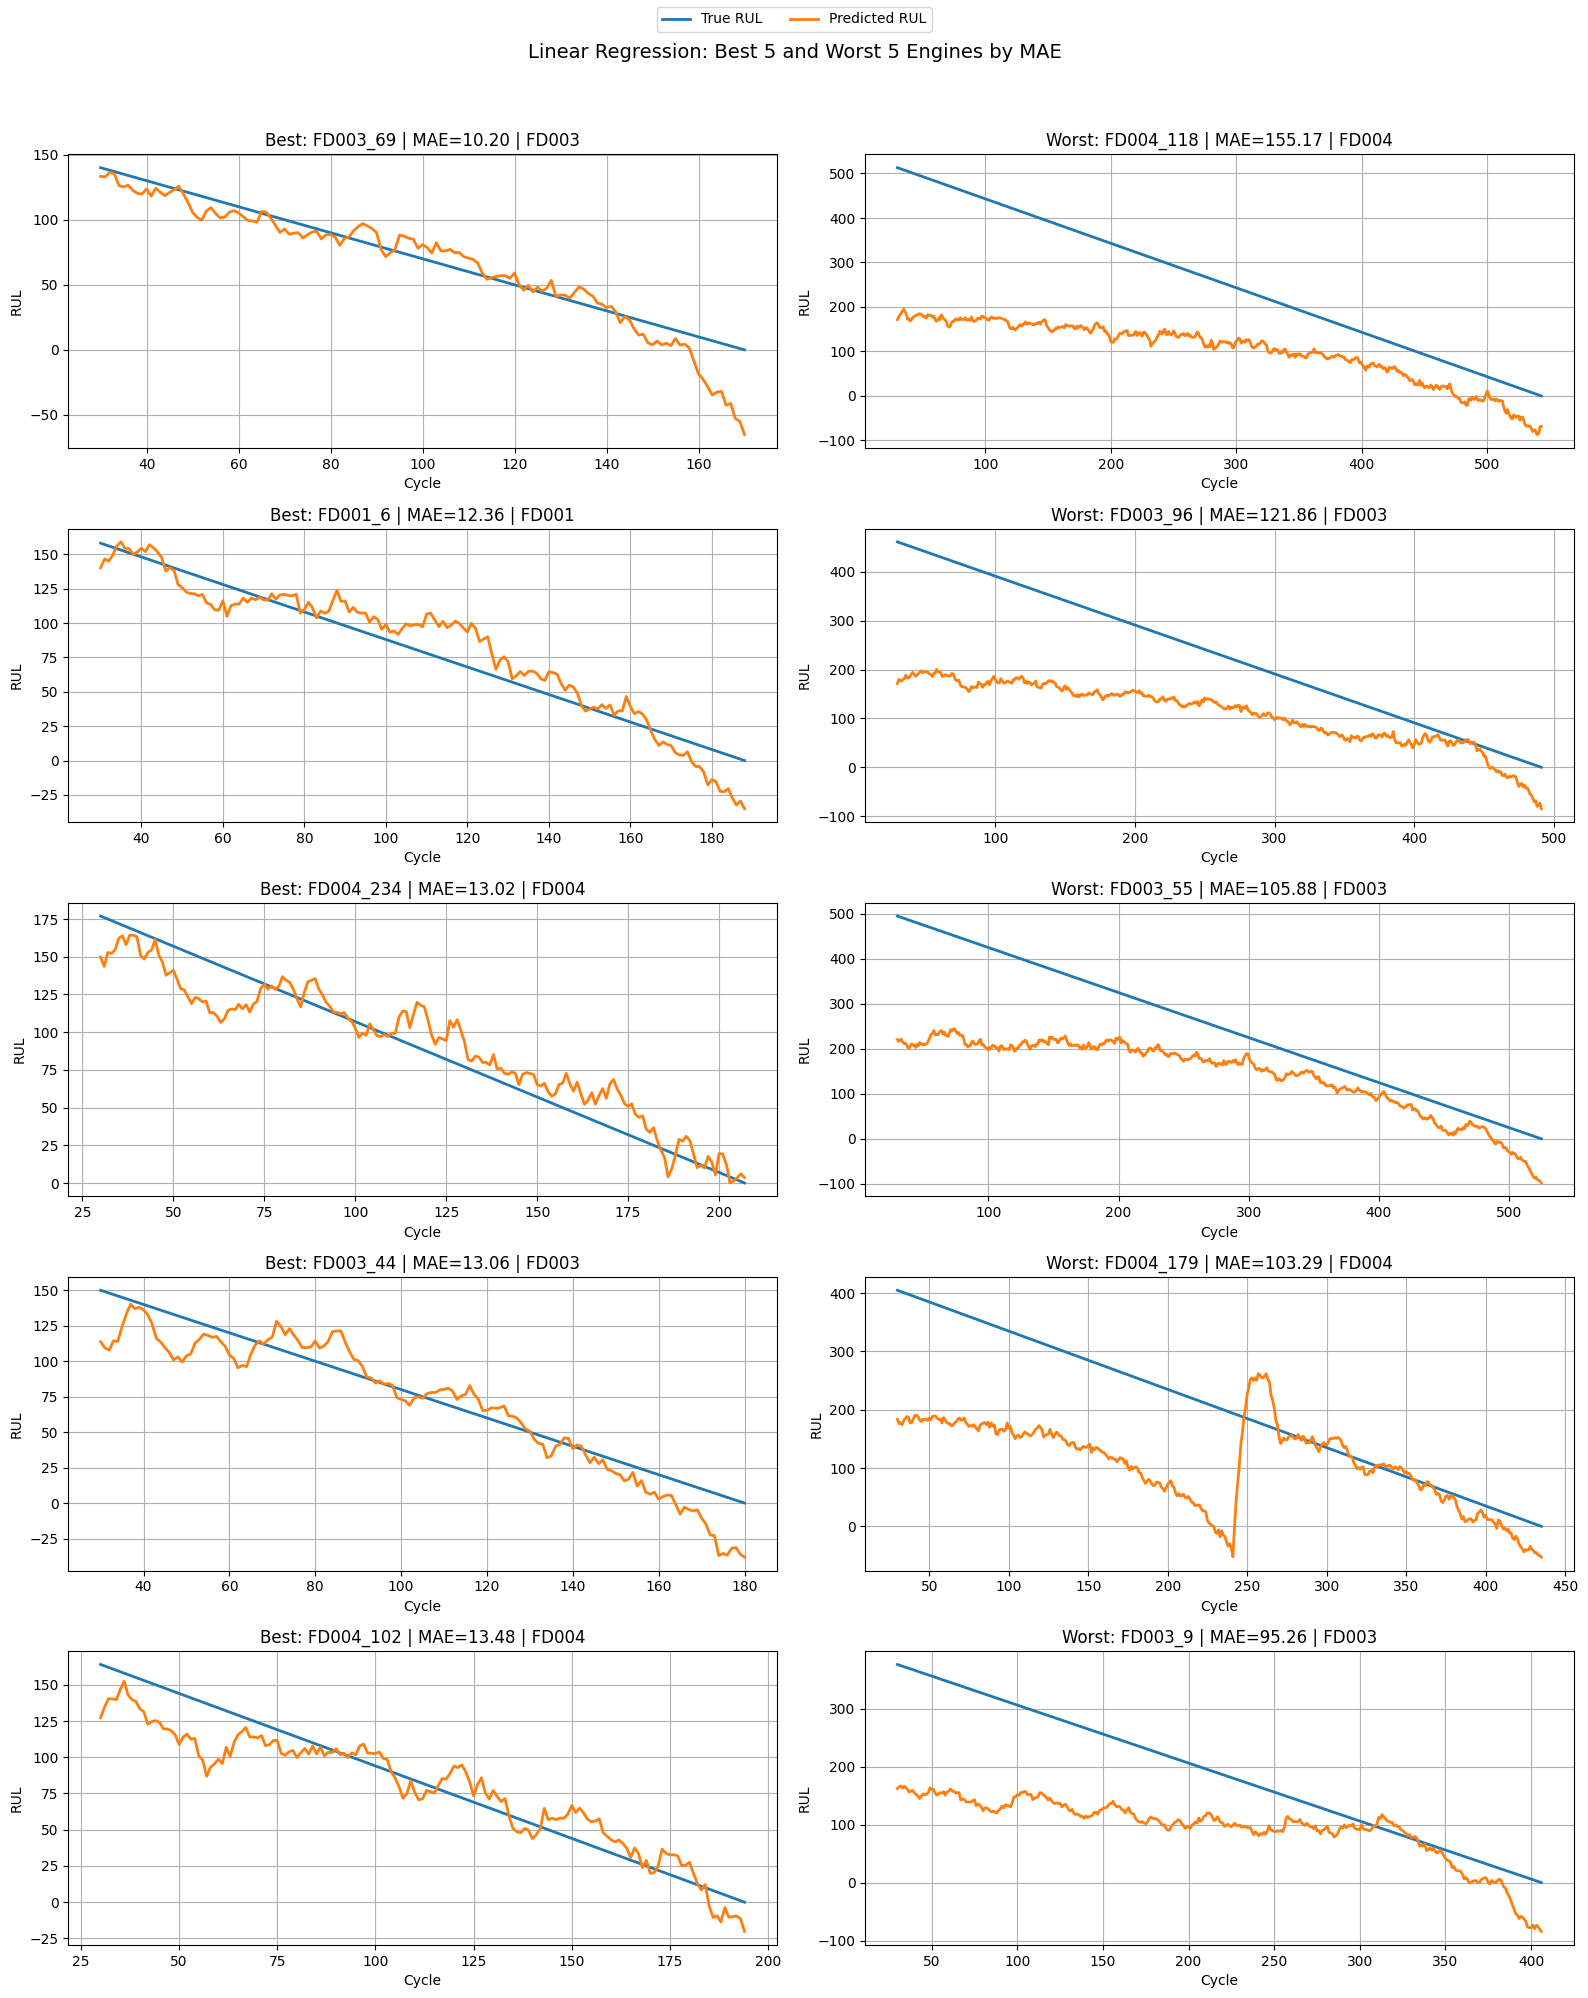

In [22]:
lr_engine_summary = plot_best_worst_engines(
    lr_backtest_results,
    n_engines=5,
    metric='mae',
    model_name='Linear Regression'
)

# Saving test results for furture use

In [23]:
lr_backtest_results.to_csv(results_dir / "lr_backtest_results.csv", index=False)
fold_results_df.to_csv(results_dir / "lr_fold_results.csv", index=False)
lr_overall_summary.to_csv(results_dir / "lr_overall_summary.csv", index=False)
lr_bucket_summary.to_csv(results_dir / "lr_bucket_summary.csv", index=False)
lr_tag_summary.to_csv(results_dir / "lr_tag_summary.csv", index=False)
lr_engine_summary.to_csv(results_dir / "lr_engine_summary.csv", index=False)

joblib.dump(per_sample_pred, results_dir / "lr_per_sample_pred.joblib")

print("Saved Linear Regression backtest outputs")

Saved Linear Regression backtest outputs


# Random forest

In [24]:
rf_per_sample_pred = np.zeros(len(y_train))
rf_fold_results = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    X_train_fold = X_train[train_idx]
    X_val_fold = X_train[val_idx]

    y_train_fold = y_train[train_idx]
    y_val_fold = y_train[val_idx]

    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train_fold, y_train_fold)

    val_pred = rf_model.predict(X_val_fold)

    rf_per_sample_pred[val_idx] = val_pred

    fold_mae = mean_absolute_error(y_val_fold, val_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_pred))
    fold_r2 = r2_score(y_val_fold, val_pred)

    rf_fold_results.append({
        'fold': fold,
        'mae': fold_mae,
        'rmse': fold_rmse,
        'r2': fold_r2,
        'train_samples': len(train_idx),
        'val_samples': len(val_idx)
    })

rf_fold_results_df = pd.DataFrame(rf_fold_results)
print(rf_fold_results_df)


   fold        mae       rmse        r2  train_samples  val_samples
0     1  32.111880  48.364400  0.616076         111818        27980
1     2  28.585857  41.408773  0.716143         111917        27881
2     3  28.941249  43.006759  0.690279         111819        27979
3     4  31.925543  47.771603  0.618047         111819        27979
4     5  28.270968  41.032978  0.719096         111819        27979


# Backtesting Results

In [25]:
rf_backtest_results = meta_train.copy()

rf_backtest_results['pred_rul'] = rf_per_sample_pred
rf_backtest_results['error'] = rf_backtest_results['pred_rul'] - rf_backtest_results['true_rul']
rf_backtest_results['abs_error'] = rf_backtest_results['error'].abs()
rf_backtest_results['squared_error'] = rf_backtest_results['error'] ** 2

print(rf_backtest_results.head())
print(rf_backtest_results.shape)

   unit_id    tag  cutoff_cycle  observed_cycles  true_rul  pred_rul  error  \
0  FD001_1  FD001            30              192     162.0    177.96  15.96   
1  FD001_1  FD001            31              192     161.0    170.03   9.03   
2  FD001_1  FD001            32              192     160.0    181.60  21.60   
3  FD001_1  FD001            33              192     159.0    178.92  19.92   
4  FD001_1  FD001            34              192     158.0    180.53  22.53   

   abs_error  squared_error  
0      15.96       254.7216  
1       9.03        81.5409  
2      21.60       466.5600  
3      19.92       396.8064  
4      22.53       507.6009  
(139798, 9)


# Checking errors per bins/batch of rul

In [26]:
rf_bucket_summary = summarize_by_rul_bucket(rf_backtest_results)
print(rf_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15  11344.0   4.979011   7.022612       7.500000      11.694834
1      16-50  24815.0  13.654791  19.268433      33.000000      43.840235
2     51-125  52619.0  27.699788  36.004014      87.685608     107.155175
3       126+  51020.0  45.798067  62.293648     191.239338     165.658201


# Checking error for Tag/data set 

In [27]:
rf_tag_summary = summarize_by_tag(rf_backtest_results)
print(rf_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
0  FD001  17731.0  100.0  23.897442  34.898003  0.682367      94.150640   
1  FD002  46219.0  260.0  25.253173  35.271149  0.678791      94.514810   
3  FD004  54028.0  249.0  33.648225  48.956012  0.656244     120.257737   
2  FD003  21820.0  100.0  35.775886  55.571206  0.646723     125.567599   

   mean_pred_rul  
0      94.782972  
1      98.136142  
3     118.818748  
2     122.591687  


# Overall backesting results of Random forest

In [28]:
rf_overall_summary = summarize_overall_metrics(rf_backtest_results)
print(rf_overall_summary)

   samples  units        mae       rmse        r2  mean_true_rul  \
0   139798    709  29.968083  44.430025  0.671803     109.264331   

   mean_pred_rul  mean_error  mean_abs_error  
0     109.521175    0.256843       29.968083  


# Plotting best and worst sets for random forest

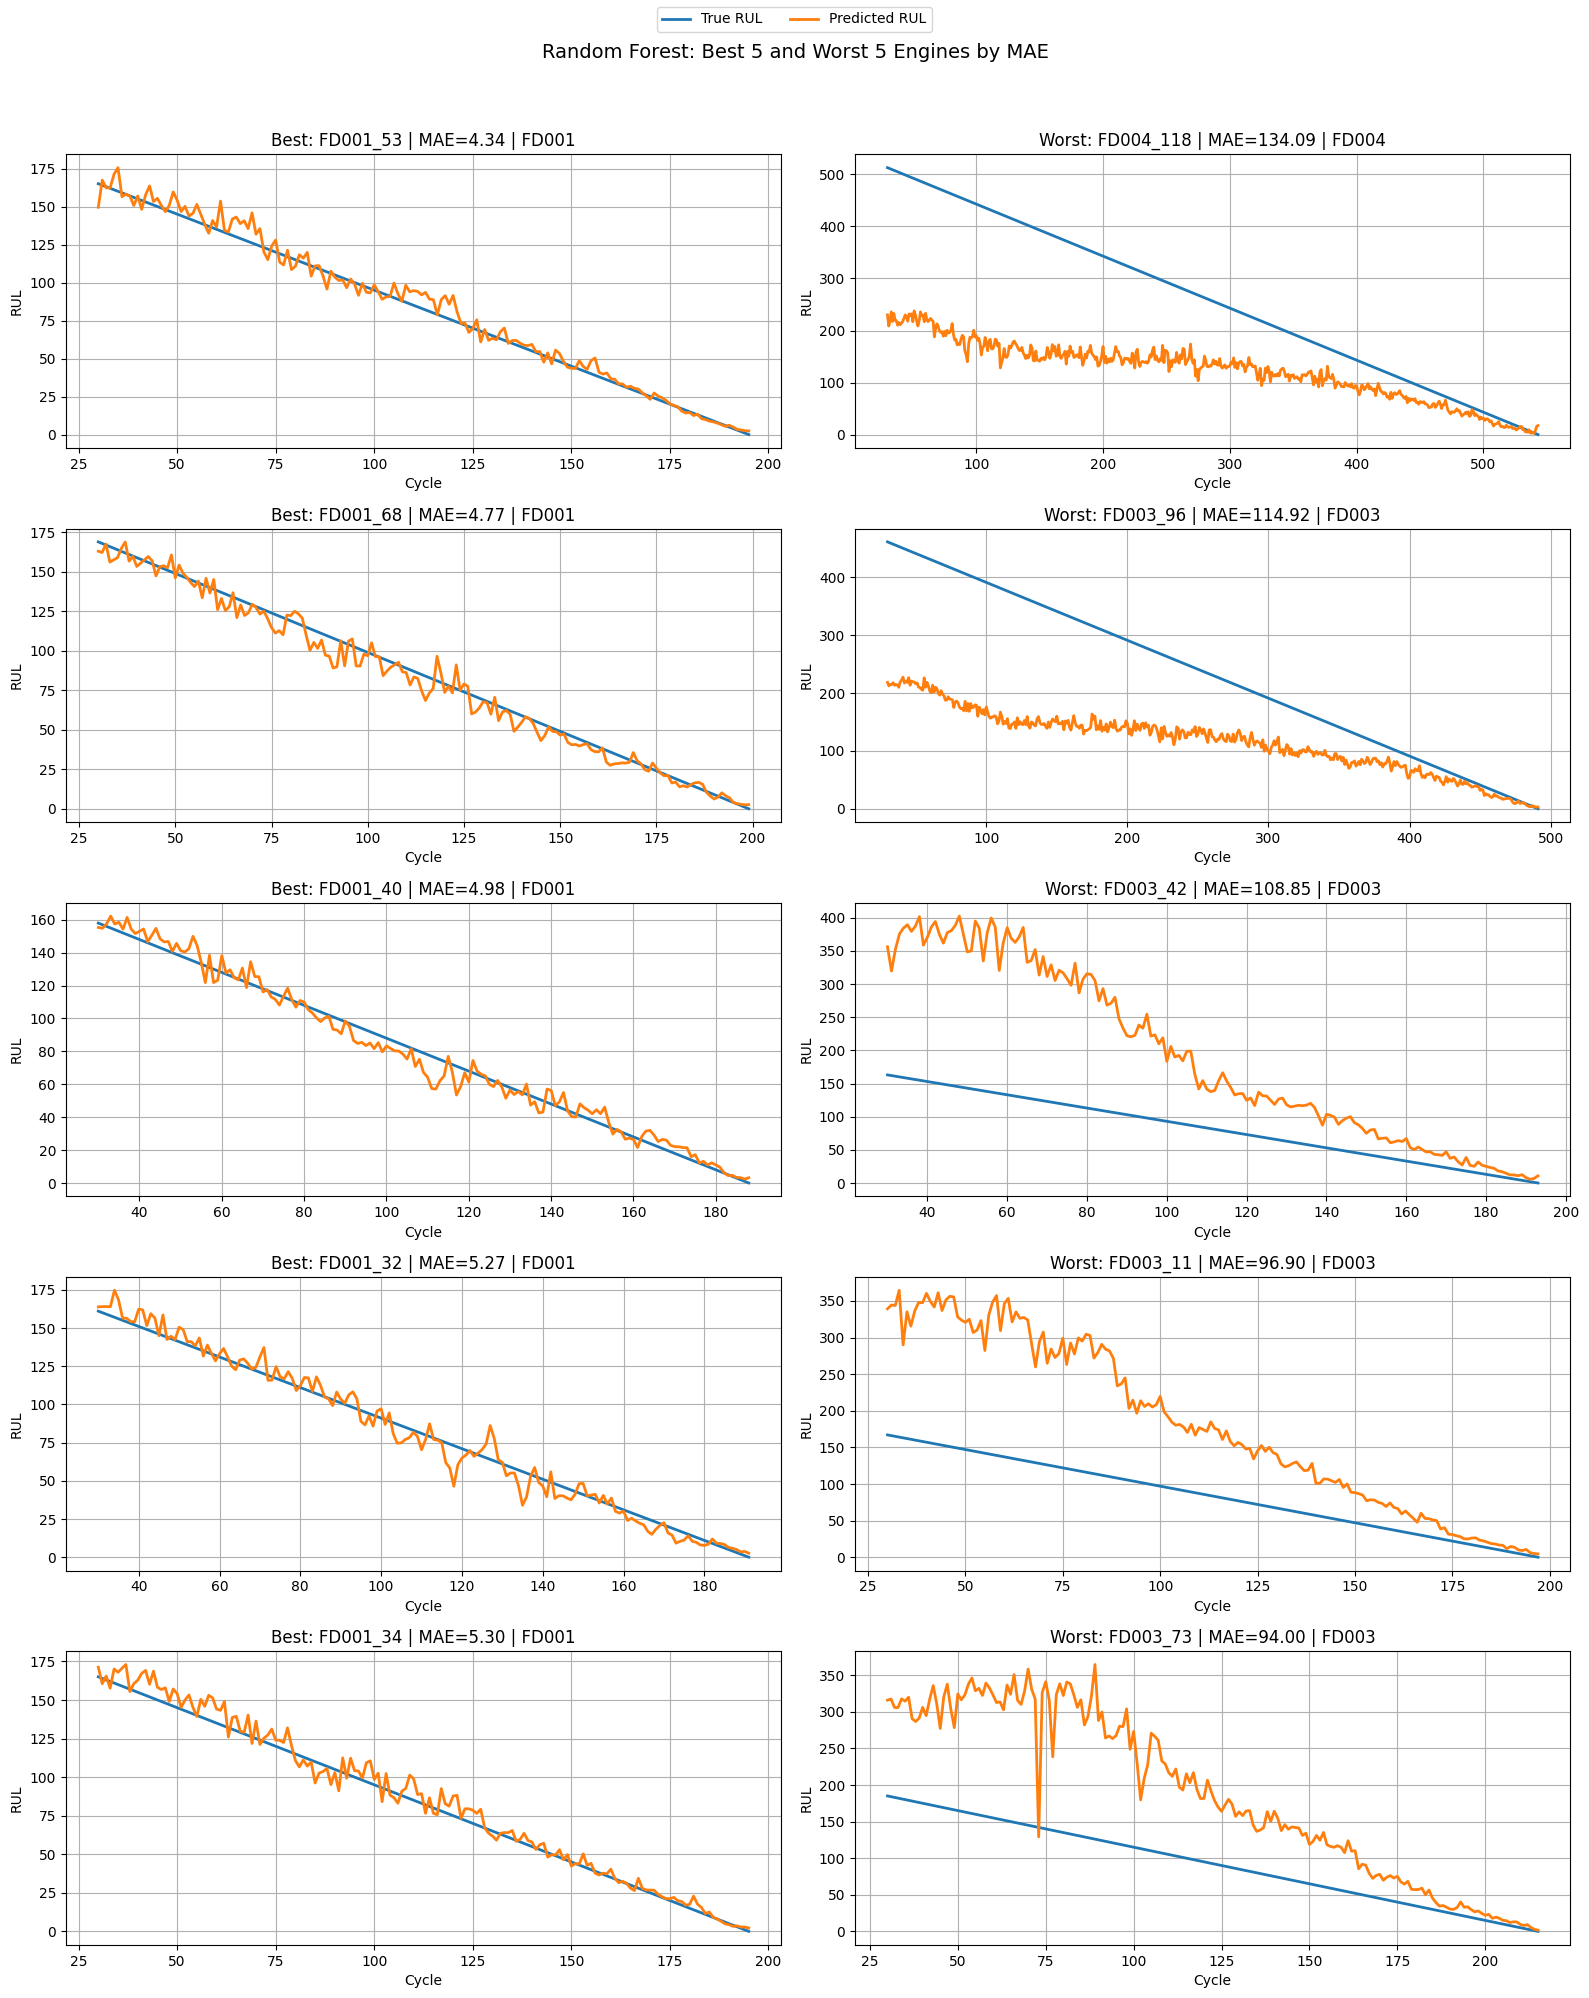

In [29]:
rf_engine_summary = plot_best_worst_engines(
    rf_backtest_results,
    n_engines=5,
    metric='mae',
    model_name='Random Forest'
)

# Saving RF backtesting for later use

In [30]:
rf_backtest_results.to_csv(results_dir / "rf_backtest_results.csv", index=False)
rf_fold_results_df.to_csv(results_dir / "rf_fold_results.csv", index=False)
rf_overall_summary.to_csv(results_dir / "rf_overall_summary.csv", index=False)
rf_bucket_summary.to_csv(results_dir / "rf_bucket_summary.csv", index=False)
rf_tag_summary.to_csv(results_dir / "rf_tag_summary.csv", index=False)
rf_engine_summary.to_csv(results_dir / "rf_engine_summary.csv", index=False)

joblib.dump(rf_per_sample_pred, results_dir / "rf_per_sample_pred.joblib")

print("Saved Random Forest backtest outputs")

Saved Random Forest backtest outputs


In [31]:
experiment_metadata = {
    'window_size': window_size,
    'feature_cols': combined_features,
    'n_splits': 5,
    'train_window_shape': X_train.shape,
    'target_shape': y_train.shape,
    'group_count': int(meta_train['unit_id'].nunique())
}

joblib.dump(experiment_metadata, results_dir / "experiment_metadata.joblib")

with open(results_dir / "experiment_metadata.json", "w") as f:
    json.dump(experiment_metadata, f, indent=2)

print("Saved experiment metadata")

Saved experiment metadata


# Final Training

# Linear Regression

In [32]:
final_lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

final_lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


# Random Forest

In [33]:
final_rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Inference phase

# Creating Test windows

In [34]:
X_test, meta_test = make_windows(
    df=df_test,
    feature_cols=combined_features,
    window_size=30,
    target_col=None,
    final_window_only=True,
    pad_short=True
)

In [35]:
print("X_test_final shape:", X_test.shape)
print("meta_test_final shape:", meta_test.shape)
print("Unique test engines:", meta_test['unit_id'].nunique())
print(meta_test.head())

X_test_final shape: (707, 660)
meta_test_final shape: (707, 4)
Unique test engines: 707
     unit_id    tag  cutoff_cycle  observed_cycles
0    FD001_1  FD001            31               31
1   FD001_10  FD001           192              192
2  FD001_100  FD001           198              198
3   FD001_11  FD001            83               83
4   FD001_12  FD001           217              217


# Linear Regressor

In [36]:
lr_test_pred = final_lr_model.predict(X_test)

print("Final Linear Regression model trained")
print("LR test predictions shape:", lr_test_pred.shape)

Final Linear Regression model trained
LR test predictions shape: (707,)


# Random Forest

In [37]:
rf_test_pred = final_rf_model.predict(X_test)

print("Final Random Forest model trained")
print("RF test predictions shape:", rf_test_pred.shape)

Final Random Forest model trained
RF test predictions shape: (707,)


# Test Results

# Linear Regression

In [38]:
lr_test_results = meta_test.copy()
lr_test_results['pred_rul'] = lr_test_pred

print(lr_test_results.head())

     unit_id    tag  cutoff_cycle  observed_cycles    pred_rul
0    FD001_1  FD001            31               31  162.637513
1   FD001_10  FD001           192              192  108.810779
2  FD001_100  FD001           198              198   19.953563
3   FD001_11  FD001            83               83  115.280875
4   FD001_12  FD001           217              217  127.857848


# Random Forest

In [39]:
rf_test_results = meta_test.copy()
rf_test_results['pred_rul'] = rf_test_pred

print(rf_test_results.head())

     unit_id    tag  cutoff_cycle  observed_cycles  pred_rul
0    FD001_1  FD001            31               31    167.11
1   FD001_10  FD001           192              192     81.27
2  FD001_100  FD001           198              198     22.18
3   FD001_11  FD001            83               83     85.73
4   FD001_12  FD001           217              217     96.97


# Adding Real RUL values

# Linear Regression

In [40]:
lr_test_results = lr_test_results.merge(
    df_rul[['unit_id', 'RUL']],
    on='unit_id',
    how='left'
).rename(columns={'RUL': 'true_rul'})

print("LR missing labels:", lr_test_results['true_rul'].isna().sum())

print(lr_test_results.head())


LR missing labels: 0
     unit_id    tag  cutoff_cycle  observed_cycles    pred_rul  true_rul
0    FD001_1  FD001            31               31  162.637513       112
1   FD001_10  FD001           192              192  108.810779        96
2  FD001_100  FD001           198              198   19.953563        20
3   FD001_11  FD001            83               83  115.280875        97
4   FD001_12  FD001           217              217  127.857848       124


# Random Forest

In [41]:
rf_test_results = rf_test_results.merge(
    df_rul[['unit_id', 'RUL']],
    on='unit_id',
    how='left'
).rename(columns={'RUL': 'true_rul'})

print("RF missing labels:", rf_test_results['true_rul'].isna().sum())
print(rf_test_results.head())


RF missing labels: 0
     unit_id    tag  cutoff_cycle  observed_cycles  pred_rul  true_rul
0    FD001_1  FD001            31               31    167.11       112
1   FD001_10  FD001           192              192     81.27        96
2  FD001_100  FD001           198              198     22.18        20
3   FD001_11  FD001            83               83     85.73        97
4   FD001_12  FD001           217              217     96.97       124


# Test Results

# Summary

In [42]:
lr_test_summary = summarize_overall_metrics(lr_test_results)
lr_test_summary['model'] = 'Linear Regression'

rf_test_summary = summarize_overall_metrics(rf_test_results)
rf_test_summary['model'] = 'Random Forest'

final_test_summary = pd.concat(
    [lr_test_summary, rf_test_summary],
    ignore_index=True
)[['model', 'samples', 'units', 'mae', 'rmse', 'r2', 'mean_true_rul', 'mean_pred_rul', 'mean_error', 'mean_abs_error']]

print(final_test_summary)

               model  samples  units        mae       rmse        r2  \
0  Linear Regression      707    707  27.253372  34.190976  0.551822   
1      Random Forest      707    707  22.990410  31.834183  0.611478   

   mean_true_rul  mean_pred_rul  mean_error  mean_abs_error  
0      81.437058      95.393085   13.956027       27.253372  
1      81.437058      93.474314   12.037256       22.990410  


# Bucket

In [43]:
lr_test_bucket_summary = summarize_by_rul_bucket(lr_test_results)
lr_test_bucket_summary['model'] = 'Linear Regression'

rf_test_bucket_summary = summarize_by_rul_bucket(rf_test_results)
rf_test_bucket_summary['model'] = 'Random Forest'

final_test_bucket_summary = pd.concat(
    [lr_test_bucket_summary, rf_test_bucket_summary],
    ignore_index=True
)
print(final_test_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul  \
0       0-15    102.0  18.508378  23.789912      10.617647       2.508201   
1      16-50    128.0  21.615665  26.407285      32.390625      48.548441   
2     51-125    327.0  32.448109  39.530778      89.409786     117.474428   
3       126+    150.0  26.686282  33.517553     154.066667     150.391576   
4       0-15    102.0   6.884608   9.334720      10.617647      16.773627   
5      16-50    128.0  11.927422  16.311391      32.390625      40.914453   
6     51-125    327.0  28.362752  36.283902      89.409786     109.672783   
7       126+    150.0  31.671067  40.252384     154.066667     155.169200   

               model  
0  Linear Regression  
1  Linear Regression  
2  Linear Regression  
3  Linear Regression  
4      Random Forest  
5      Random Forest  
6      Random Forest  
7      Random Forest  


# Tag

In [44]:
lr_test_tag_summary = summarize_by_tag(lr_test_results)
lr_test_tag_summary['model'] = 'Linear Regression'

rf_test_tag_summary = summarize_by_tag(rf_test_results)
rf_test_tag_summary['model'] = 'Random Forest'

final_test_tag_summary = pd.concat(
    [lr_test_tag_summary, rf_test_tag_summary],
    ignore_index=True
)
print(final_test_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
0  FD002    259.0  259.0  24.526385  29.952332  0.689802      81.185328   
1  FD001    100.0  100.0  26.248364  32.158335  0.401137      75.520000   
2  FD004    248.0  248.0  27.578590  34.898358  0.590327      86.552419   
3  FD003    100.0  100.0  34.514734  43.437931 -0.101107      75.320000   
4  FD001    100.0  100.0  18.544400  23.712597  0.674389      75.520000   
5  FD002    259.0  259.0  20.627876  28.209799  0.724845      81.185328   
6  FD003    100.0  100.0  25.226500  35.241632  0.275225      75.320000   
7  FD004    248.0  248.0  26.348831  36.475148  0.552470      86.552419   

   mean_pred_rul              model  
0      90.605162  Linear Regression  
1      95.393930  Linear Regression  
2      99.058639  Linear Regression  
3      98.702389  Linear Regression  
4      86.598400      Random Forest  
5      88.852432      Random Forest  
6      94.198700      Random Forest  
7     100.781653    

# Plot

In [45]:
def plot_final_test_predictions(results_df, model_name='Model'):
    plt.figure(figsize=(7, 7))
    plt.scatter(results_df['true_rul'], results_df['pred_rul'], alpha=0.6)

    min_val = min(results_df['true_rul'].min(), results_df['pred_rul'].min())
    max_val = max(results_df['true_rul'].max(), results_df['pred_rul'].max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('True RUL')
    plt.ylabel('Predicted RUL')
    plt.title(f'{model_name}: Official Test True vs Predicted RUL')
    plt.legend()
    plt.grid(True)
    plt.show()

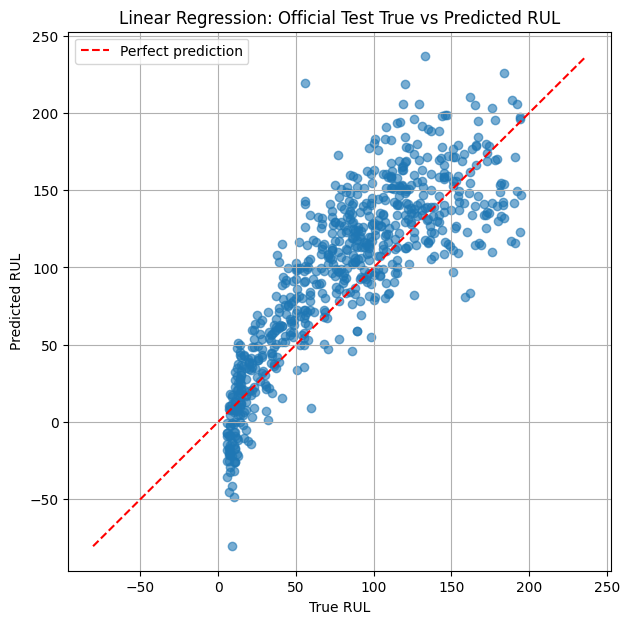

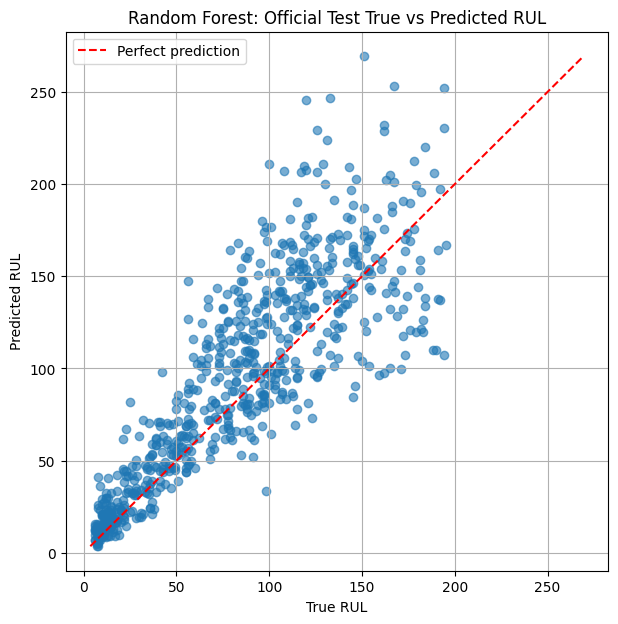

In [46]:
plot_final_test_predictions(lr_test_results, model_name='Linear Regression')
plot_final_test_predictions(rf_test_results, model_name='Random Forest')

# Saving results

# CSV's

In [47]:
lr_test_results.to_csv(final_results_dir / "lr_test_results.csv", index=False)
rf_test_results.to_csv(final_results_dir / "rf_test_results.csv", index=False)

final_test_summary.to_csv(final_results_dir / "final_test_summary.csv", index=False)
final_test_bucket_summary.to_csv(final_results_dir / "final_test_bucket_summary.csv", index=False)
final_test_tag_summary.to_csv(final_results_dir / "final_test_tag_summary.csv", index=False)

print("Saved final official test CSV outputs")

Saved final official test CSV outputs


# Pandas Dataframes

In [48]:
joblib.dump(lr_test_results, final_results_dir / "lr_test_results.joblib")
joblib.dump(rf_test_results, final_results_dir / "rf_test_results.joblib")

joblib.dump(final_test_summary, final_results_dir / "final_test_summary.joblib")
joblib.dump(final_test_bucket_summary, final_results_dir / "final_test_bucket_summary.joblib")
joblib.dump(final_test_tag_summary, final_results_dir / "final_test_tag_summary.joblib")

print("Saved final official test joblib outputs")

Saved final official test joblib outputs


# Final MetaData

In [49]:
final_test_metadata = {
    'window_size': window_size,
    'feature_count': len(combined_features),
    'feature_cols': combined_features,
    'n_test_engines': int(meta_test['unit_id'].nunique()),
    'x_test_shape': tuple(X_test.shape)
}

joblib.dump(final_test_metadata, final_results_dir / "final_test_metadata.joblib")

print("Saved final test metadata")

Saved final test metadata


# Saving the models and metadata

In [50]:
# Linear regressor
joblib.dump(final_lr_model, model_dir / "final_linear_regression.joblib")
print("Saved final Linear Regression model")

# Random Forest
joblib.dump(final_rf_model, model_dir / "final_random_forest.joblib")
print("Saved final Random Forest model")

#Meta data about the model and input shapes for future reference
model_metadata = {
    'feature_cols': combined_features,
    'window_size': window_size,
    'stride': 1,
    'train_input_shape': X_train.shape,
    'test_input_shape': X_test.shape,
    'model_input_type': 'flat_window_sequence_to_one_rul'
}

joblib.dump(model_metadata, model_dir / "model_metadata.joblib")

with open(model_dir / "model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Saved model metadata")

Saved final Linear Regression model
Saved final Random Forest model
Saved model metadata


# Final Summary

In [51]:
lr_backtest_summary_final = lr_overall_summary.copy()
lr_backtest_summary_final['model'] = 'Linear Regression'
lr_backtest_summary_final['evaluation'] = 'Backtest'

rf_backtest_summary_final = rf_overall_summary.copy()
rf_backtest_summary_final['model'] = 'Random Forest'
rf_backtest_summary_final['evaluation'] = 'Backtest'

lr_test_summary_final = lr_test_summary.copy()
lr_test_summary_final['model'] = 'Linear Regression'
lr_test_summary_final['evaluation'] = 'Official Test'

rf_test_summary_final = rf_test_summary.copy()
rf_test_summary_final['model'] = 'Random Forest'
rf_test_summary_final['evaluation'] = 'Official Test'

final_comparison_table = pd.concat([
    lr_backtest_summary_final,
    rf_backtest_summary_final,
    lr_test_summary_final,
    rf_test_summary_final
], ignore_index=True)

final_comparison_table = final_comparison_table[
    ['model', 'evaluation', 'samples', 'units', 'mae', 'rmse', 'r2',
     'mean_true_rul', 'mean_pred_rul', 'mean_error', 'mean_abs_error']
]

print(final_comparison_table)

               model     evaluation  samples  units        mae       rmse  \
0  Linear Regression       Backtest   139798    709  34.881590  47.872139   
1      Random Forest       Backtest   139798    709  29.968083  44.430025   
2  Linear Regression  Official Test      707    707  27.253372  34.190976   
3      Random Forest  Official Test      707    707  22.990410  31.834183   

         r2  mean_true_rul  mean_pred_rul  mean_error  mean_abs_error  
0  0.618981     109.264331     109.033765   -0.230566       34.881590  
1  0.671803     109.264331     109.521175    0.256843       29.968083  
2  0.551822      81.437058      95.393085   13.956027       27.253372  
3  0.611478      81.437058      93.474314   12.037256       22.990410  


# Save Summary

In [55]:
final_comparison_table.to_csv(final_results_dir / "final_model_comparison.csv", index=False)
print("Saved final model comparison table")

Saved final model comparison table


# Load and predict

In [56]:
# final_lr_model = joblib.load("./saved_models/final_linear_regression.joblib")
# final_rf_model = joblib.load("./saved_models/final_random_forest.joblib")
# model_metadata = joblib.load("./saved_models/model_metadata.joblib")

# print("Loaded final models and metadata")

# lr_test_pred = final_lr_model.predict(X_test)
# rf_test_pred = final_rf_model.predict(X_test)

# LSTM

In [57]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce GTX 1650


# Creating window sequence for LSTM

In [58]:
def make_sequence_windows(
    df,
    feature_cols,
    window_size=30,
    group_col='unit_id',
    time_col='time_cycles',
    target_col='RUL',
    tag_col='tag',
    stride=1
):
    df = df.sort_values([group_col, time_col]).copy()

    X_list = []
    y_list = []
    meta_rows = []

    for unit_id, group in df.groupby(group_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        if len(group) < window_size:
            continue

        for end_idx in range(window_size - 1, len(group), stride):
            start_idx = end_idx - window_size + 1

            window_df = group.iloc[start_idx:end_idx + 1]

            seq_features = window_df[feature_cols].to_numpy(dtype=float)

            X_list.append(seq_features)
            y_list.append(group.iloc[end_idx][target_col])

            meta_rows.append({
                'unit_id': unit_id,
                'tag': group.iloc[end_idx][tag_col],
                'cutoff_cycle': int(group.iloc[end_idx][time_col]),
                'true_rul': float(group.iloc[end_idx][target_col])
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_rows)

    return X, y, meta

In [59]:
X_seq, y_seq, meta_seq = make_sequence_windows(
    df=df_train,
    feature_cols=combined_features,
    window_size=window_size,
    stride=1
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print(meta_seq.head())


X_seq shape: (139798, 30, 22)
y_seq shape: (139798,)
   unit_id    tag  cutoff_cycle  true_rul
0  FD001_1  FD001            30     162.0
1  FD001_1  FD001            31     161.0
2  FD001_1  FD001            32     160.0
3  FD001_1  FD001            33     159.0
4  FD001_1  FD001            34     158.0


# Splitting train and test data

In [60]:
groups_seq = meta_seq['unit_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_seq, val_idx_seq = next(gss.split(X_seq, y_seq, groups=groups_seq))

X_seq_train = X_seq[train_idx_seq]
X_seq_val = X_seq[val_idx_seq]

y_seq_train = y_seq[train_idx_seq]
y_seq_val = y_seq[val_idx_seq]

meta_seq_train = meta_seq.iloc[train_idx_seq].reset_index(drop=True)
meta_seq_val = meta_seq.iloc[val_idx_seq].reset_index(drop=True)

In [61]:
print("Train shape:", X_seq_train.shape, y_seq_train.shape)
print("Val shape  :", X_seq_val.shape, y_seq_val.shape)
print("Train engines:", meta_seq_train['unit_id'].nunique())
print("Val engines  :", meta_seq_val['unit_id'].nunique())

Train shape: (112586, 30, 22) (112586,)
Val shape  : (27212, 30, 22) (27212,)
Train engines: 567
Val engines  : 142


# Converting NumPy array to tensor for torch models

In [62]:
X_train_tensor = torch.tensor(X_seq_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_seq_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_seq_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_seq_val, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [63]:
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

X_train_tensor shape: torch.Size([112586, 30, 22])
y_train_tensor shape: torch.Size([112586, 1])
X_val_tensor shape: torch.Size([27212, 30, 22])
y_val_tensor shape: torch.Size([27212, 1])
Number of training batches: 1760
Number of validation batches: 426


# Defining LSTM regressor model

In [64]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        last_hidden = hidden[-1]
        output = self.fc(last_hidden)
        return output

# Initializing the model

In [65]:
input_size = X_seq_train.shape[2]       # Features

#Creating the model
lstm_model = LSTMRegressor(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

print(lstm_model)
print("Input size:", input_size)

LSTMRegressor(
  (lstm): LSTM(22, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Input size: 22


# Defining Loss function and optimizer

In [66]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Function to evaluate the model

In [67]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = np.vstack(all_preds).ravel()
    all_targets = np.vstack(all_targets).ravel()

    return avg_loss, all_preds, all_targets

# Train Initial LSTM

In [68]:
num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    lstm_model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = lstm_model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    epoch_val_loss, val_preds, val_targets = evaluate_model(
        model=lstm_model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )


Epoch [1/50] | Train Loss: 10319.7515 | Val Loss: 5160.4739
Epoch [2/50] | Train Loss: 3860.6291 | Val Loss: 2441.5302
Epoch [3/50] | Train Loss: 2374.6678 | Val Loss: 1955.3743
Epoch [4/50] | Train Loss: 1983.3020 | Val Loss: 1742.3449
Epoch [5/50] | Train Loss: 1800.4590 | Val Loss: 1772.8201
Epoch [6/50] | Train Loss: 1725.8792 | Val Loss: 1676.3106
Epoch [7/50] | Train Loss: 1654.0365 | Val Loss: 1846.3776
Epoch [8/50] | Train Loss: 1585.2919 | Val Loss: 1687.6575
Epoch [9/50] | Train Loss: 1549.7903 | Val Loss: 1711.7807
Epoch [10/50] | Train Loss: 1494.5025 | Val Loss: 1786.9745
Epoch [11/50] | Train Loss: 1470.6237 | Val Loss: 2217.8213
Epoch [12/50] | Train Loss: 1435.5169 | Val Loss: 1747.6258
Epoch [13/50] | Train Loss: 1412.7029 | Val Loss: 1818.6943
Epoch [14/50] | Train Loss: 1380.5141 | Val Loss: 1907.6796
Epoch [15/50] | Train Loss: 1339.4784 | Val Loss: 1916.5350
Epoch [16/50] | Train Loss: 1332.5228 | Val Loss: 1886.9409
Epoch [17/50] | Train Loss: 1296.9908 | Val Loss

# Evaluation

In [69]:
val_mae = mean_absolute_error(val_targets, val_preds)
val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
val_r2 = r2_score(val_targets, val_preds)

print(f"LSTM Validation MAE : {val_mae:.2f}")
print(f"LSTM Validation RMSE: {val_rmse:.2f}")
print(f"LSTM Validation R2  : {val_r2:.2f}")

lstm_val_results = meta_seq_val.copy()
lstm_val_results['pred_rul'] = val_preds
lstm_val_results['error'] = lstm_val_results['pred_rul'] - lstm_val_results['true_rul']
lstm_val_results['abs_error'] = np.abs(lstm_val_results['error'])

print(lstm_val_results.head())


LSTM Validation MAE : 32.27
LSTM Validation RMSE: 50.39
LSTM Validation R2  : 0.56
     unit_id    tag  cutoff_cycle  true_rul    pred_rul      error  abs_error
0  FD001_100  FD001            30     170.0  252.958878  82.958878  82.958878
1  FD001_100  FD001            31     169.0  232.655991  63.655991  63.655991
2  FD001_100  FD001            32     168.0  220.801956  52.801956  52.801956
3  FD001_100  FD001            33     167.0  213.442673  46.442673  46.442673
4  FD001_100  FD001            34     166.0  206.983398  40.983398  40.983398


# Error's

# Range/Buckets if RUL

In [70]:
lstm_bucket_summary = summarize_by_rul_bucket(lstm_val_results)
print(lstm_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15   2272.0   4.934211   7.610262       7.500000       9.962856
1      16-50   4970.0  10.396816  15.199786      33.000000      38.908062
2     51-125  10556.0  30.274599  43.344555      87.725464     108.327477
3       126+   9414.0  52.662201  71.388811     188.313469     180.666031


# By tag/dataset

In [71]:
lstm_tag_summary = summarize_by_tag(lstm_val_results)
print(lstm_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
0  FD001   4251.0   26.0  19.876029  30.454670  0.638661      83.304399   
1  FD002  10749.0   61.0  26.285550  38.190981  0.592313      92.758024   
3  FD004   8443.0   39.0  41.028702  60.193766  0.469060     119.365628   
2  FD003   3769.0   16.0  43.720250  70.770541  0.523358     138.200053   

   mean_pred_rul  
0      93.205818  
1      96.902641  
3     133.362625  
2     131.732147  


# Overall summary

In [72]:
lstm_overall_summary = summarize_overall_metrics(lstm_val_results)
print(lstm_overall_summary)

   samples  units        mae       rmse        r2  mean_true_rul  \
0    27212    142  32.273384  50.387688  0.557345     105.830626   

   mean_pred_rul  mean_error  mean_abs_error  
0      112.46154    6.630919       32.273384  


# Plot

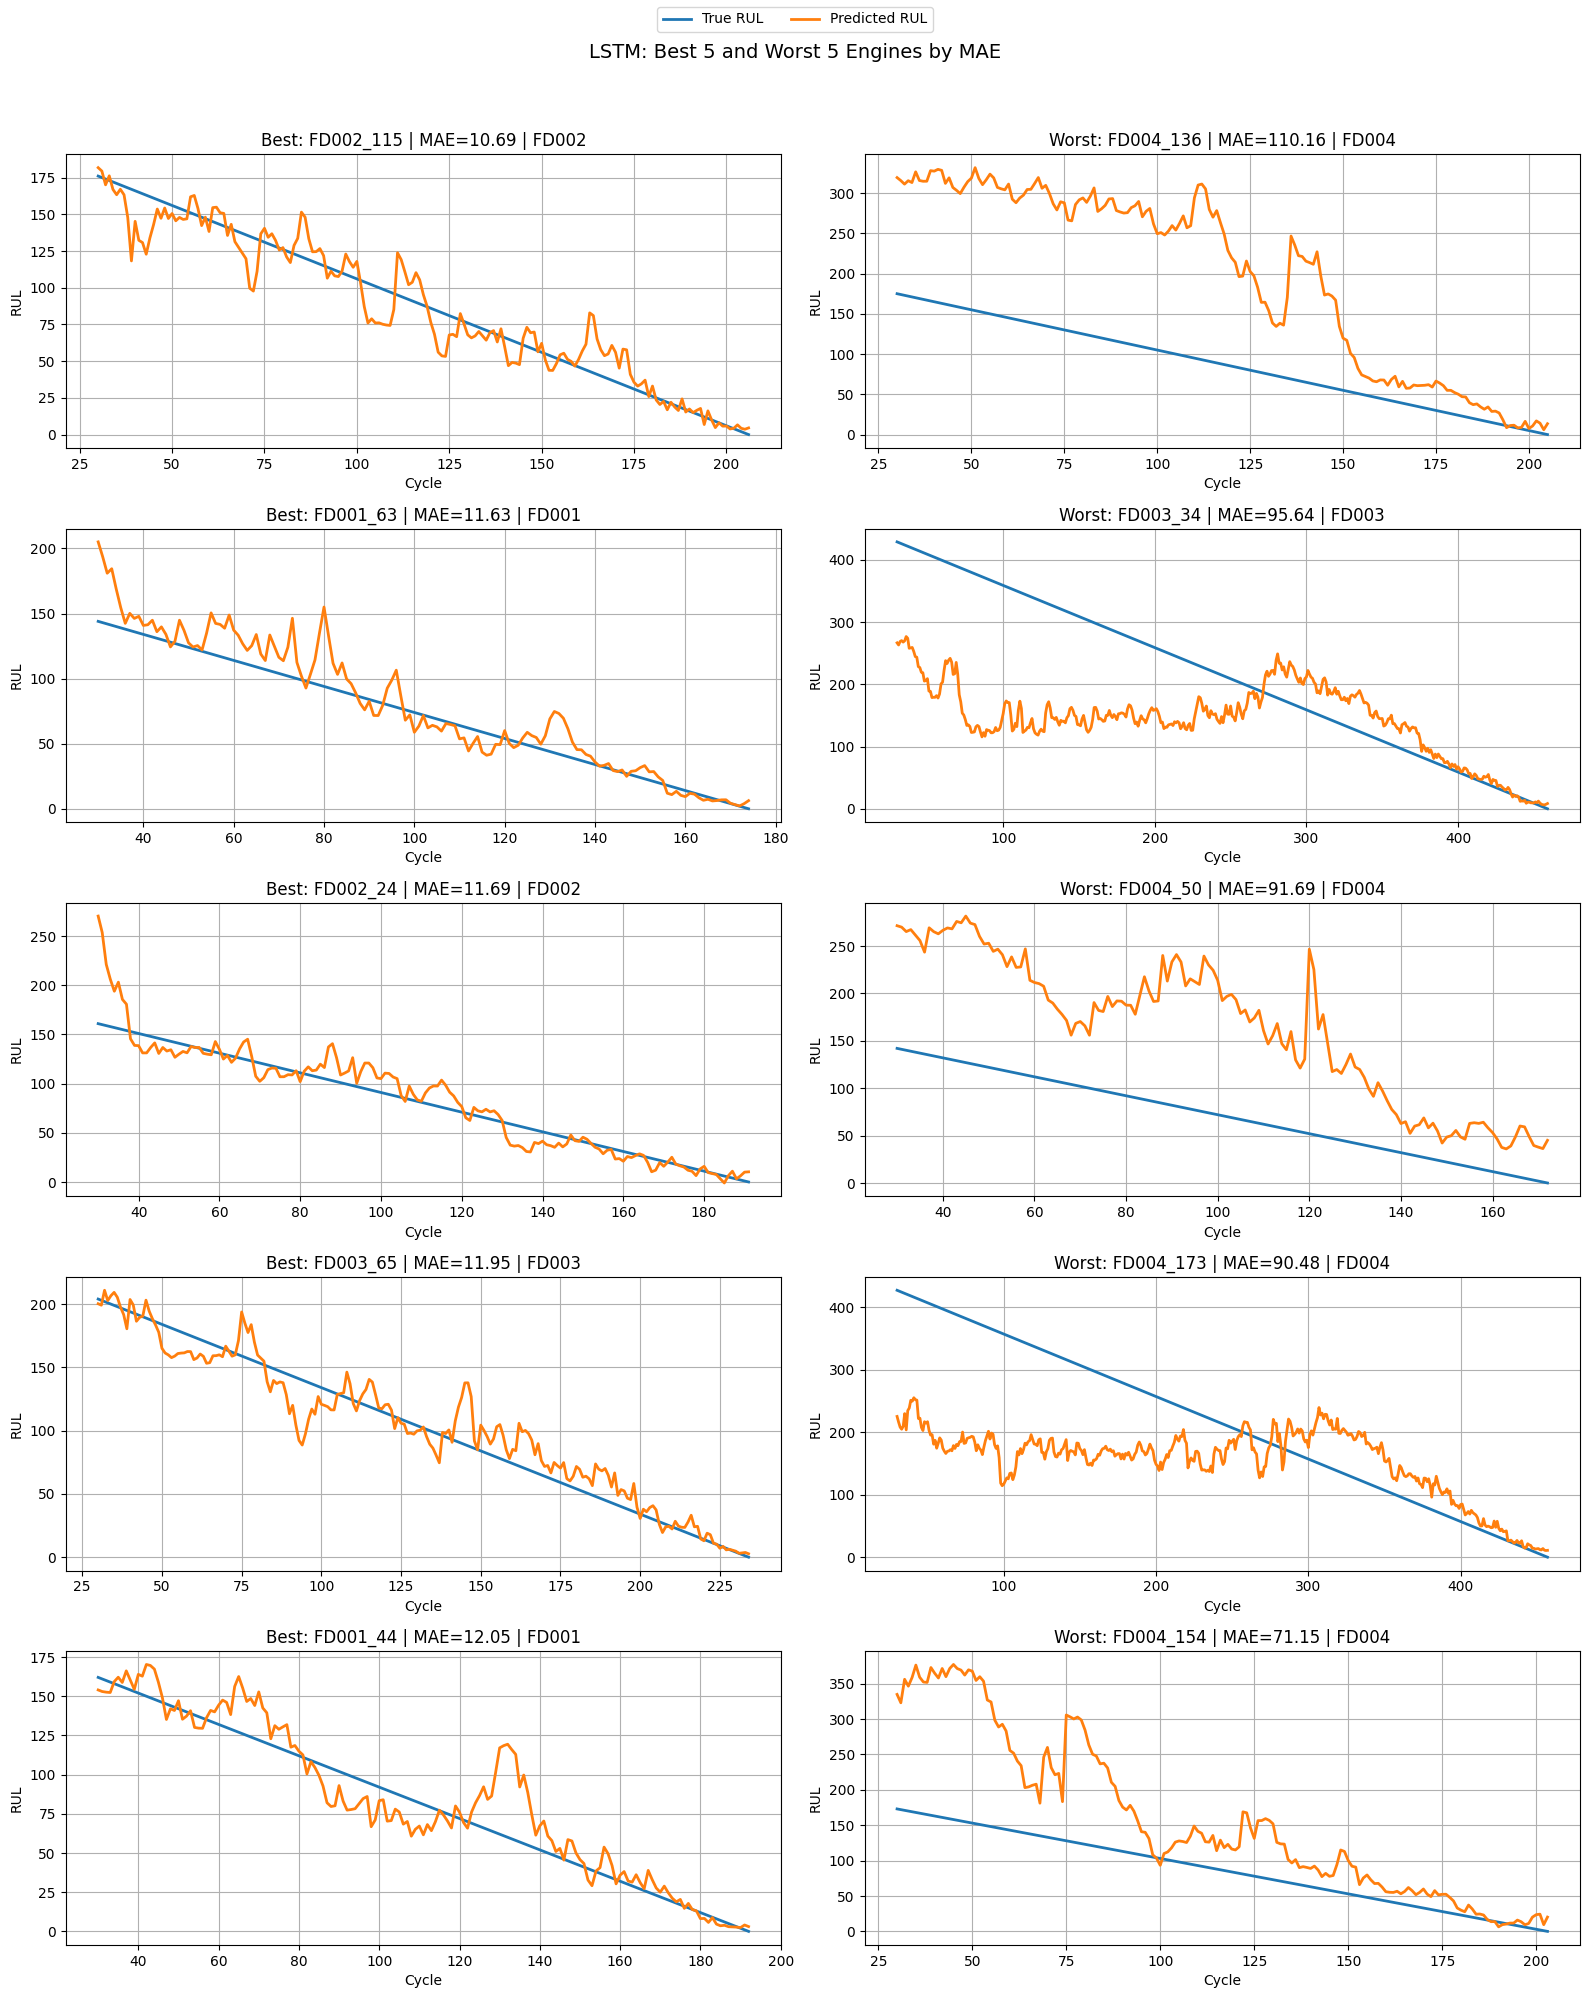

       unit_id        mae       rmse    tag
0    FD001_100  21.983292  30.783310  FD001
1     FD001_14  13.323108  19.970302  FD001
2     FD001_18  14.940223  22.705414  FD001
3     FD001_36  14.171043  19.810158  FD001
4     FD001_37  24.010244  31.173617  FD001
..         ...        ...        ...    ...
137   FD004_84  28.520212  35.765637  FD004
138   FD004_87  29.455477  40.111890  FD004
139   FD004_88  22.276976  31.280813  FD004
140   FD004_95  39.198821  53.713088  FD004
141   FD004_96  27.396356  34.133023  FD004

[142 rows x 4 columns]


In [73]:
lstm_engine_summary = plot_best_worst_engines(
    lstm_val_results,
    n_engines=5,
    metric='mae',
    model_name='LSTM'
)

print(lstm_engine_summary)

# Plotting training and validation loss curve

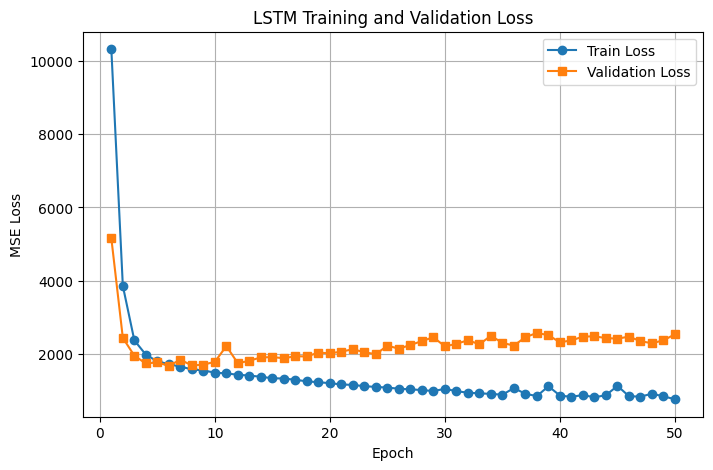

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Observation

- From this curve we can note that model generalizes well at epoch of less than 10

# Creating a new optimized model with this model and this optimized model is used further

# Retraning a new model with epoch 6 since training loss and validation loss completly overlap

In [75]:
lstm_model_optimized = LSTMRegressor(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

optimized_criterion = nn.MSELoss()
optimized_optimizer = torch.optim.Adam(lstm_model_optimized.parameters(), lr=0.001)

optimized_num_epochs = 6

optimized_train_losses = []
optimized_val_losses = []

for epoch in range(optimized_num_epochs):
    lstm_model_optimized.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimized_optimizer.zero_grad()

        preds = lstm_model_optimized(X_batch)
        loss = optimized_criterion(preds, y_batch)

        loss.backward()
        optimized_optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    epoch_val_loss, optimized_val_preds, optimized_val_targets = evaluate_model(
        model=lstm_model_optimized,
        data_loader=val_loader,
        criterion=optimized_criterion,
        device=device
    )

    optimized_train_losses.append(epoch_train_loss)
    optimized_val_losses.append(epoch_val_loss)

    print(
        f"Optimized Epoch [{epoch + 1}/{optimized_num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Optimized Epoch [1/6] | Train Loss: 9742.8415 | Val Loss: 4628.1555
Optimized Epoch [2/6] | Train Loss: 3610.1874 | Val Loss: 2419.4674
Optimized Epoch [3/6] | Train Loss: 2345.5666 | Val Loss: 2041.5952
Optimized Epoch [4/6] | Train Loss: 1986.3627 | Val Loss: 1766.4105
Optimized Epoch [5/6] | Train Loss: 1826.2992 | Val Loss: 1754.4025
Optimized Epoch [6/6] | Train Loss: 1720.2156 | Val Loss: 1778.3768


# Error evaluation

In [76]:
optimized_val_mae = mean_absolute_error(optimized_val_targets, optimized_val_preds)
optimized_val_rmse = np.sqrt(mean_squared_error(optimized_val_targets, optimized_val_preds))
optimized_val_r2 = r2_score(optimized_val_targets, optimized_val_preds)

print(f"Optimized LSTM Validation MAE : {optimized_val_mae:.2f}")
print(f"Optimized LSTM Validation RMSE: {optimized_val_rmse:.2f}")
print(f"Optimized LSTM Validation R2  : {optimized_val_r2:.2f}")

Optimized LSTM Validation MAE : 29.29
Optimized LSTM Validation RMSE: 42.17
Optimized LSTM Validation R2  : 0.69


In [77]:
lstm_optimized_val_results = meta_seq_val.copy()

lstm_optimized_val_results['pred_rul'] = optimized_val_preds
lstm_optimized_val_results['error'] = (lstm_optimized_val_results['pred_rul'] - lstm_optimized_val_results['true_rul'])
lstm_optimized_val_results['abs_error'] = np.abs(lstm_optimized_val_results['error'])

print(lstm_optimized_val_results.head())

     unit_id    tag  cutoff_cycle  true_rul    pred_rul      error  abs_error
0  FD001_100  FD001            30     170.0  206.635025  36.635025  36.635025
1  FD001_100  FD001            31     169.0  196.301880  27.301880  27.301880
2  FD001_100  FD001            32     168.0  195.162308  27.162308  27.162308
3  FD001_100  FD001            33     167.0  191.916245  24.916245  24.916245
4  FD001_100  FD001            34     166.0  192.740555  26.740555  26.740555


# Group/Bucket error

In [78]:
lstm_optimized_bucket_summary = summarize_by_rul_bucket(lstm_optimized_val_results)
print(lstm_optimized_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15   2272.0   8.296699   9.549873       7.500000      15.686044
1      16-50   4970.0  12.337712  17.425024      33.000000      43.021084
2     51-125  10556.0  31.418986  40.768626      87.725464     113.532982
3       126+   9414.0  40.922580  55.628598     188.313469     177.169540


# Tag / Dataset error

In [79]:
lstm_optimized_tag_summary = summarize_by_tag(lstm_optimized_val_results)
print(lstm_optimized_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
0  FD001   4251.0   26.0  20.802115  27.301659  0.709607      83.304399   
1  FD002  10749.0   61.0  23.540159  32.334445  0.707763      92.758024   
3  FD004   8443.0   39.0  36.504689  49.686440  0.638242     119.365628   
2  FD003   3769.0   16.0  39.108638  59.051333  0.668146     138.200053   

   mean_pred_rul  
0      98.833885  
1      98.997734  
3     134.148911  
2     132.367432  


# Overall summary

In [80]:
lstm_optimized_overall_summary = summarize_overall_metrics(lstm_optimized_val_results)
print(lstm_optimized_overall_summary)


   samples  units        mae       rmse        r2  mean_true_rul  \
0    27212    142  29.291214  42.170805  0.689944     105.830626   

   mean_pred_rul  mean_error  mean_abs_error  
0     114.500275    8.669652       29.291214  


# Plotting 5 best and 5 worst

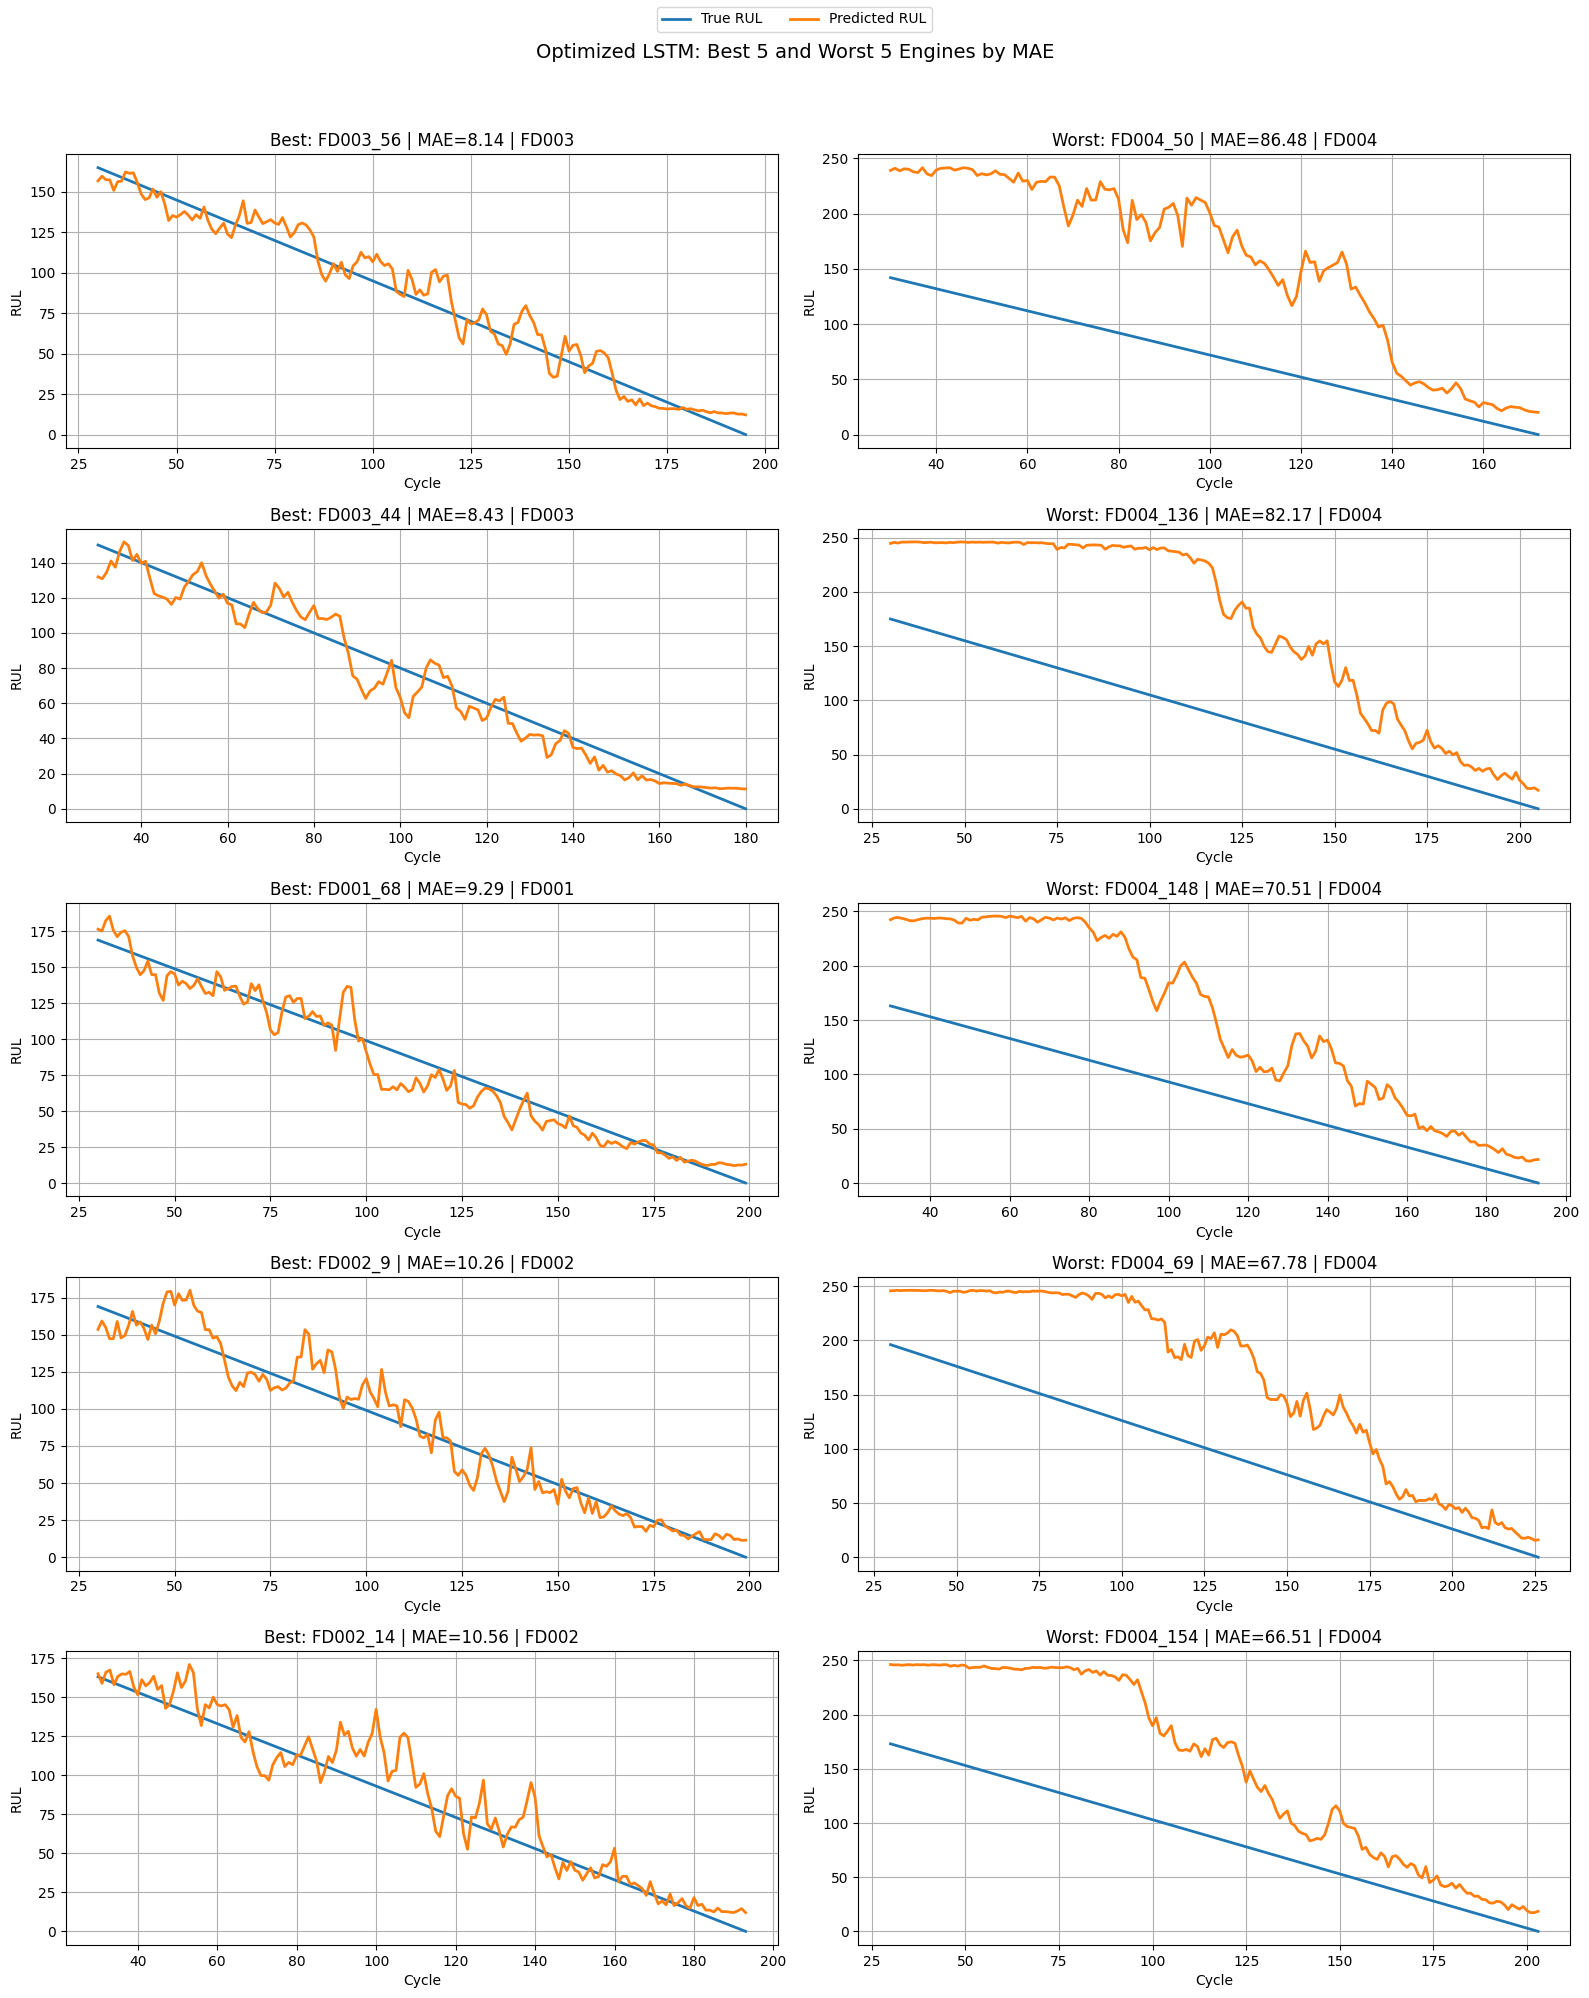

       unit_id        mae       rmse    tag
0    FD001_100  16.826915  22.475742  FD001
1     FD001_14  18.249681  25.650973  FD001
2     FD001_18  20.974201  25.081616  FD001
3     FD001_36  20.710635  27.961441  FD001
4     FD001_37  26.541005  33.942476  FD001
..         ...        ...        ...    ...
137   FD004_84  39.551495  44.219054  FD004
138   FD004_87  21.425709  24.654994  FD004
139   FD004_88  31.244232  41.760314  FD004
140   FD004_95  42.148512  48.310294  FD004
141   FD004_96  39.521078  46.500810  FD004

[142 rows x 4 columns]


In [81]:
lstm_optimized_engine_summary = plot_best_worst_engines(
    lstm_optimized_val_results,
    n_engines=5,
    metric='mae',
    model_name='Optimized LSTM'
)

print(lstm_optimized_engine_summary)

# Plotting training / validation curve

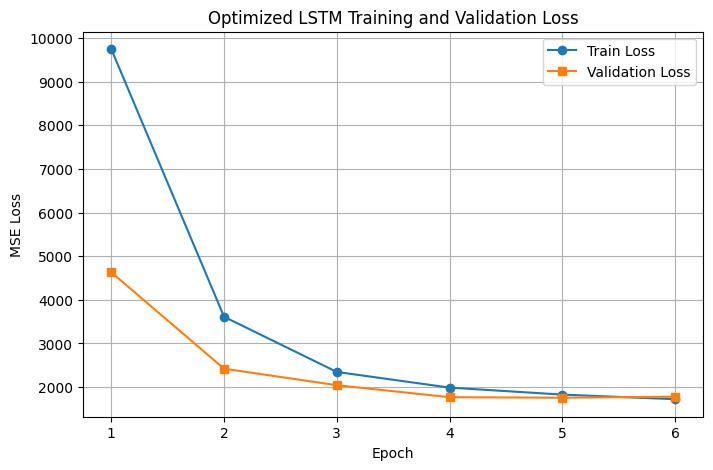

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, optimized_num_epochs + 1), optimized_train_losses, marker='o', label='Train Loss')
plt.plot(range(1, optimized_num_epochs + 1), optimized_val_losses, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Optimized LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Comparing initial and optimized model

In [83]:
lstm_comparison = pd.DataFrame([
    {
        'model': 'Initial LSTM',
        'epochs': num_epochs,
        'mae': val_mae,
        'rmse': val_rmse,
        'r2': val_r2
    },
    {
        'model': 'Optimized LSTM',
        'epochs': optimized_num_epochs,
        'mae': optimized_val_mae,
        'rmse': optimized_val_rmse,
        'r2': optimized_val_r2
    }
])

print(lstm_comparison)


            model  epochs        mae       rmse        r2
0    Initial LSTM      50  32.273384  50.387686  0.557345
1  Optimized LSTM       6  29.291212  42.170807  0.689944


# Backtesting

# Creating fold indecies

In [84]:
groups_seq = meta_seq['unit_id']

gkf_seq = GroupKFold(n_splits=5)
cv_splits_seq = list(gkf_seq.split(X_seq, y_seq, groups=groups_seq))

for fold, (train_idx, val_idx) in enumerate(cv_splits_seq, start=1):
    print(f"Fold {fold}")
    print("Train samples:", len(train_idx))
    print("Validation samples:", len(val_idx))
    print("Train engines:", meta_seq.iloc[train_idx]['unit_id'].nunique())
    print("Validation engines:", meta_seq.iloc[val_idx]['unit_id'].nunique())
    print("-" * 40)

Fold 1
Train samples: 111818
Validation samples: 27980
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 2
Train samples: 111917
Validation samples: 27881
Train engines: 568
Validation engines: 141
----------------------------------------
Fold 3
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 4
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------
Fold 5
Train samples: 111819
Validation samples: 27979
Train engines: 567
Validation engines: 142
----------------------------------------


# Creating actual folds tensors for training and testing

In [85]:
lstm_per_sample_pred = np.zeros(len(y_seq), dtype=np.float32)
lstm_fold_results = []

lstm_num_epochs = 10
lstm_batch_size = 64

for fold, (train_idx, val_idx) in enumerate(cv_splits_seq, start=1):
    print(f"\nStarting Fold {fold}")

    X_train_fold = X_seq[train_idx]
    X_val_fold = X_seq[val_idx]

    y_train_fold = y_seq[train_idx]
    y_val_fold = y_seq[val_idx]

    X_train_fold_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)

    X_val_fold_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)

    train_fold_dataset = TensorDataset(X_train_fold_tensor, y_train_fold_tensor)
    val_fold_dataset = TensorDataset(X_val_fold_tensor, y_val_fold_tensor)

    train_fold_loader = DataLoader(train_fold_dataset, batch_size=lstm_batch_size, shuffle=True)
    val_fold_loader = DataLoader(val_fold_dataset, batch_size=lstm_batch_size, shuffle=False)

    print("Train fold shape:", X_train_fold.shape, y_train_fold.shape)
    print("Val fold shape  :", X_val_fold.shape, y_val_fold.shape)
    print("Train engines:", meta_seq.iloc[train_idx]['unit_id'].nunique())
    print("Val engines  :", meta_seq.iloc[val_idx]['unit_id'].nunique())

    fold_model = LSTMRegressor(
        input_size=X_seq.shape[2],
        hidden_size=64,
        num_layers=1,
        dropout=0.0
    ).to(device)

    fold_criterion = nn.MSELoss()
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=0.001)

    for epoch in range(lstm_num_epochs):
        fold_model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_fold_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            fold_optimizer.zero_grad()

            preds = fold_model(X_batch)
            loss = fold_criterion(preds, y_batch)

            loss.backward()
            fold_optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_fold_loader.dataset)

    fold_val_loss, fold_val_preds, fold_val_targets = evaluate_model(
        model=fold_model,
        data_loader=val_fold_loader,
        criterion=fold_criterion,
        device=device
    )

    lstm_per_sample_pred[val_idx] = fold_val_preds

    fold_mae = mean_absolute_error(fold_val_targets, fold_val_preds)
    fold_rmse = np.sqrt(mean_squared_error(fold_val_targets, fold_val_preds))
    fold_r2 = r2_score(fold_val_targets, fold_val_preds)

    lstm_fold_results.append({
        'fold': fold,
        'mae': fold_mae,
        'rmse': fold_rmse,
        'r2': fold_r2,
        'train_samples': len(train_idx),
        'val_samples': len(val_idx)
    })

    print(
        f"Fold {fold} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {fold_val_loss:.4f} | "
        f"MAE: {fold_mae:.2f} | "
        f"RMSE: {fold_rmse:.2f} | "
        f"R2: {fold_r2:.2f}"
    )



Starting Fold 1
Train fold shape: (111818, 30, 22) (111818,)
Val fold shape  : (27980, 30, 22) (27980,)
Train engines: 567
Val engines  : 142
Fold 1 | Train Loss: 1459.5059 | Val Loss: 2113.7067 | MAE: 30.43 | RMSE: 45.98 | R2: 0.65

Starting Fold 2
Train fold shape: (111917, 30, 22) (111917,)
Val fold shape  : (27881, 30, 22) (27881,)
Train engines: 568
Val engines  : 141
Fold 2 | Train Loss: 1583.4293 | Val Loss: 1656.4721 | MAE: 27.98 | RMSE: 40.70 | R2: 0.73

Starting Fold 3
Train fold shape: (111819, 30, 22) (111819,)
Val fold shape  : (27979, 30, 22) (27979,)
Train engines: 567
Val engines  : 142
Fold 3 | Train Loss: 1572.5372 | Val Loss: 1690.9476 | MAE: 26.84 | RMSE: 41.12 | R2: 0.72

Starting Fold 4
Train fold shape: (111819, 30, 22) (111819,)
Val fold shape  : (27979, 30, 22) (27979,)
Train engines: 567
Val engines  : 142
Fold 4 | Train Loss: 1500.5876 | Val Loss: 2168.9225 | MAE: 31.98 | RMSE: 46.57 | R2: 0.64

Starting Fold 5
Train fold shape: (111819, 30, 22) (111819,)
Va

# Backtesting Results

In [86]:
lstm_fold_results_df = pd.DataFrame(lstm_fold_results)
print(lstm_fold_results_df)

lstm_backtest_results = meta_seq.copy()
lstm_backtest_results['pred_rul'] = lstm_per_sample_pred
lstm_backtest_results['error'] = lstm_backtest_results['pred_rul'] - lstm_backtest_results['true_rul']
lstm_backtest_results['abs_error'] = np.abs(lstm_backtest_results['error'])

print(lstm_backtest_results.head())
print("Backtest results shape:", lstm_backtest_results.shape)
print("Unique engines in backtest:", lstm_backtest_results['unit_id'].nunique())

   fold        mae       rmse        r2  train_samples  val_samples
0     1  30.426819  45.975067  0.653072         111818        27980
1     2  27.978050  40.699779  0.725780         111917        27881
2     3  26.838076  41.121134  0.716843         111819        27979
3     4  31.976238  46.571693  0.636994         111819        27979
4     5  28.821716  40.885783  0.721107         111819        27979
   unit_id    tag  cutoff_cycle  true_rul    pred_rul      error  abs_error
0  FD001_1  FD001            30     162.0  182.447983  20.447983  20.447983
1  FD001_1  FD001            31     161.0  182.708755  21.708755  21.708755
2  FD001_1  FD001            32     160.0  181.912994  21.912994  21.912994
3  FD001_1  FD001            33     159.0  180.752975  21.752975  21.752975
4  FD001_1  FD001            34     158.0  173.551468  15.551468  15.551468
Backtest results shape: (139798, 7)
Unique engines in backtest: 709


# Bucket/RUL group errors

In [87]:
lstm_backtest_bucket_summary = summarize_by_rul_bucket(lstm_backtest_results)
print(lstm_backtest_bucket_summary)

  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15  11344.0   6.800390   8.422745       7.500000      13.733987
1      16-50  24815.0  11.082476  16.059359      33.000000      39.334530
2     51-125  52619.0  27.661807  36.722771      87.685608     106.393150
3       126+  51020.0  44.603586  59.714353     191.239338     170.319763


# Tag/ dataset errors

In [88]:
lstm_backtest_tag_summary = summarize_by_tag(lstm_backtest_results)
print(lstm_backtest_tag_summary)

     tag  samples  units        mae       rmse        r2  mean_true_rul  \
0  FD001  17731.0  100.0  23.026306  33.808685  0.701887      94.150640   
1  FD002  46219.0  260.0  24.660978  34.964985  0.684343      94.514810   
3  FD004  54028.0  249.0  33.384953  48.178622  0.667075     120.257737   
2  FD003  21820.0  100.0  33.527015  51.517387  0.696385     125.567599   

   mean_pred_rul  
0      95.318535  
1      97.186501  
3     121.931541  
2     121.458641  


# Overall summary

In [89]:
lstm_backtest_overall_summary = summarize_overall_metrics(lstm_backtest_results)
print(lstm_backtest_overall_summary)

   samples  units        mae       rmse        r2  mean_true_rul  \
0   139798    709  29.209051  43.133328  0.690681     109.264331   

   mean_pred_rul  mean_error  mean_abs_error  
0     110.301292    1.036964       29.209051  


# Plotting best and worst

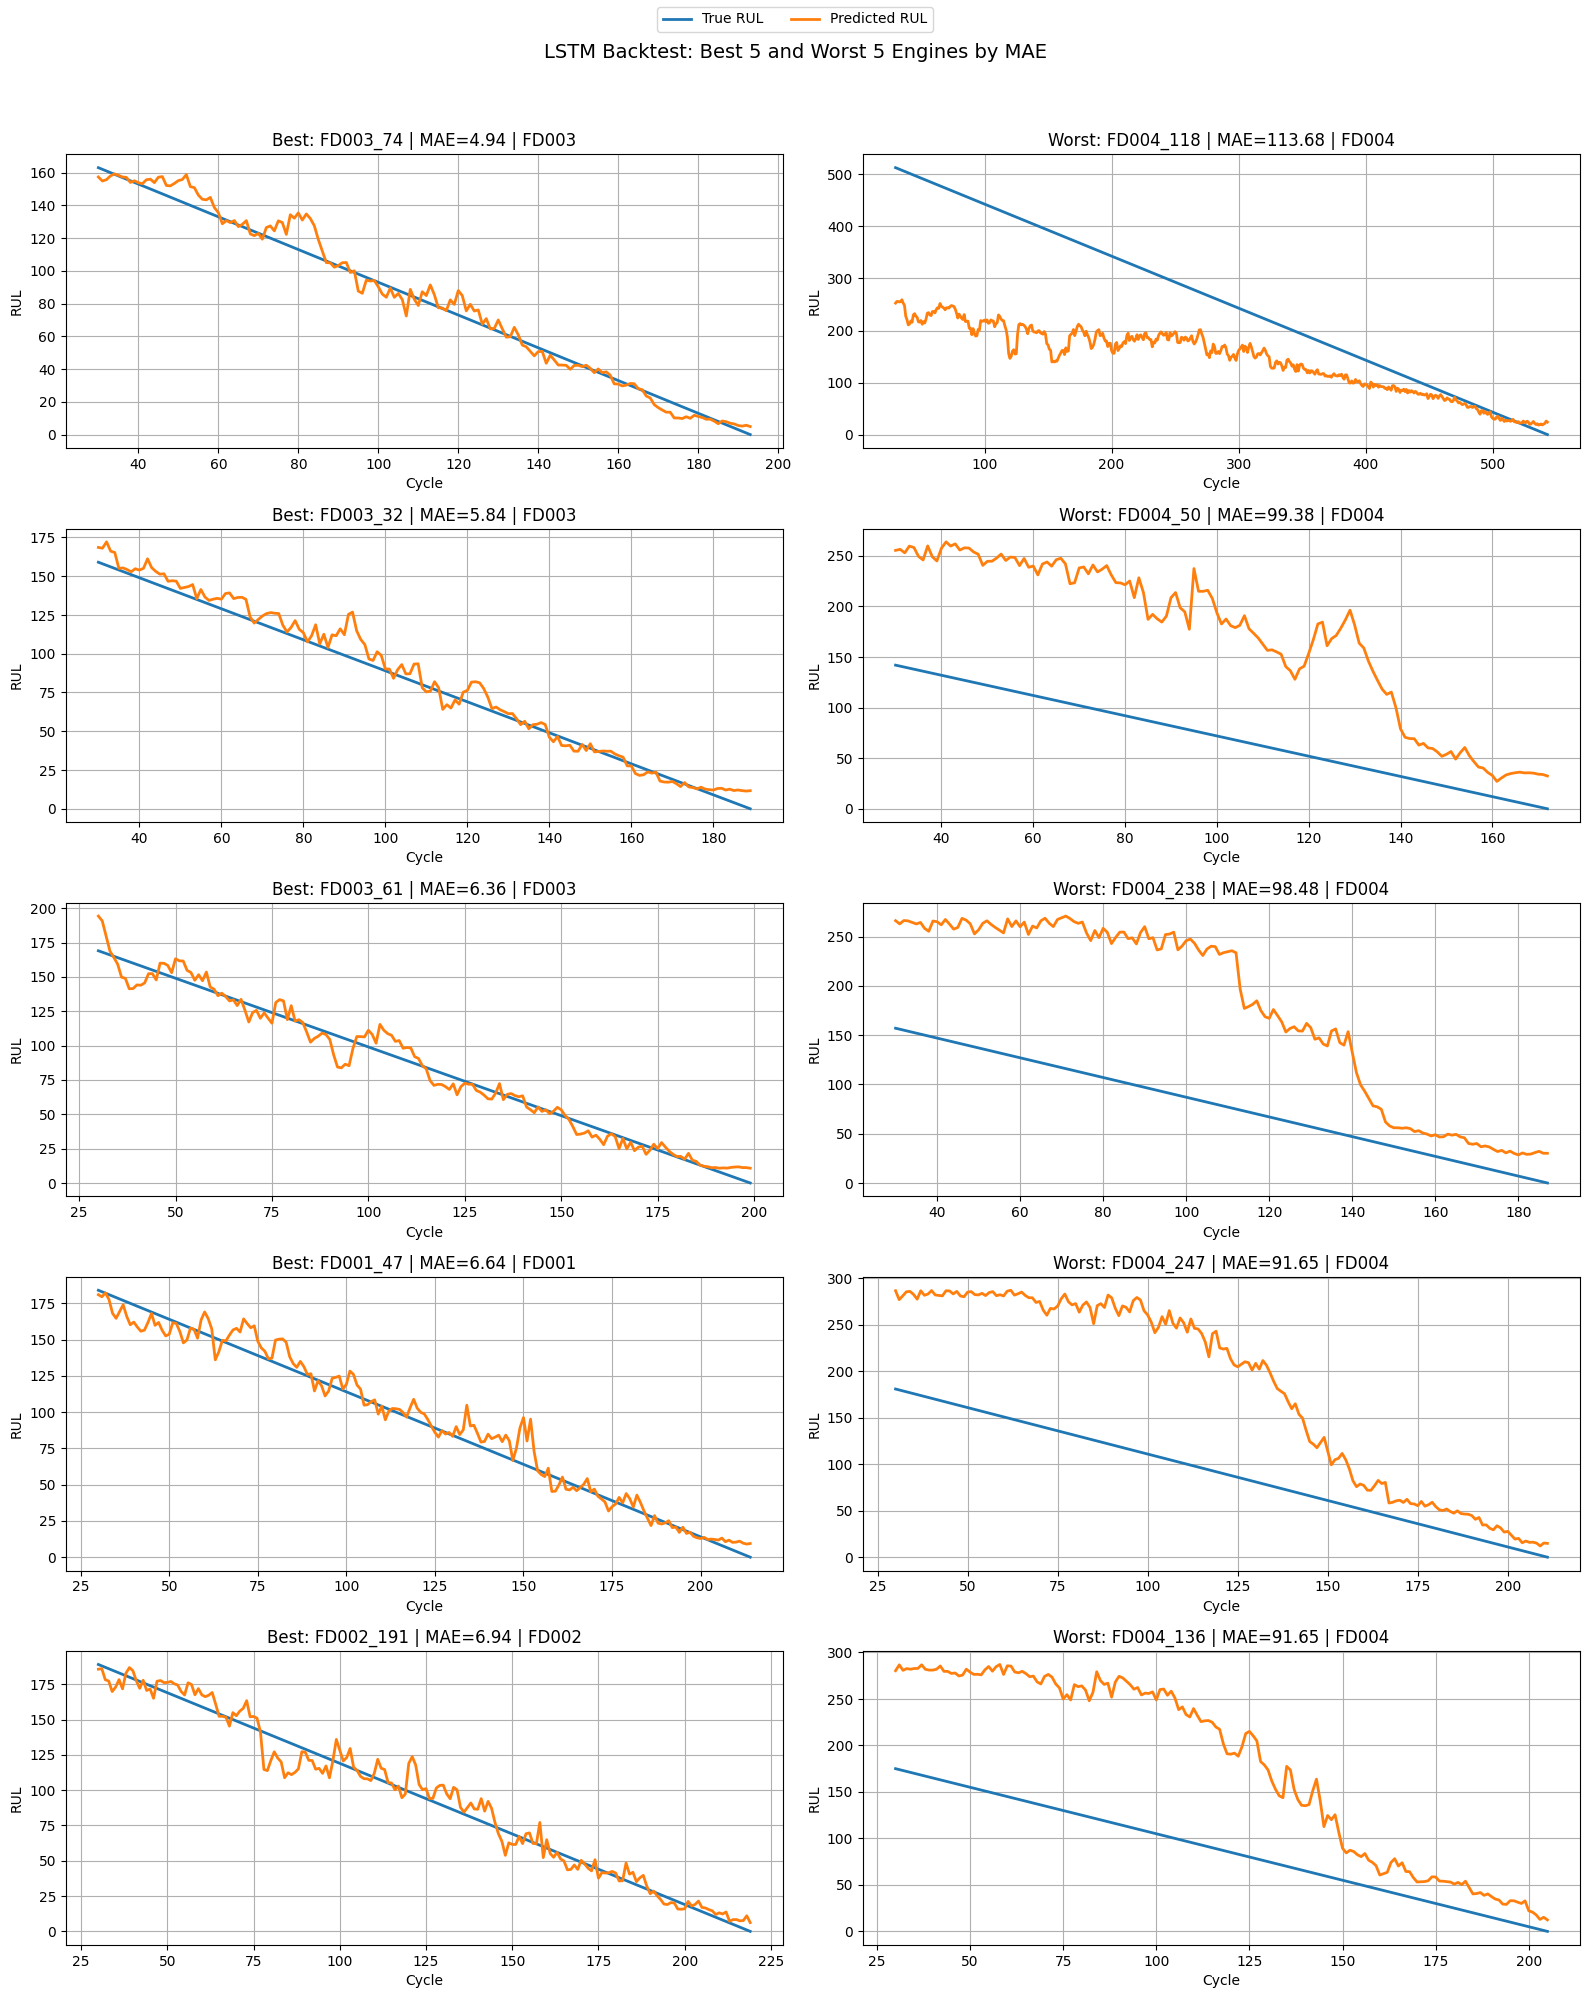

       unit_id        mae       rmse    tag
0      FD001_1  20.241586  28.184634  FD001
1     FD001_10  16.129482  21.413813  FD001
2    FD001_100  14.545193  19.410463  FD001
3     FD001_11  10.269746  13.935956  FD001
4     FD001_12  17.200795  21.066120  FD001
..         ...        ...        ...    ...
704   FD004_95  44.187357  52.749817  FD004
705   FD004_96  32.215431  37.521767  FD004
706   FD004_97  20.169021  28.009307  FD004
707   FD004_98   9.581554  13.152290  FD004
708   FD004_99  22.363274  28.669357  FD004

[709 rows x 4 columns]


In [90]:
lstm_backtest_engine_summary = plot_best_worst_engines(
    lstm_backtest_results,
    n_engines=5,
    metric='mae',
    model_name='LSTM Backtest'
)

print(lstm_backtest_engine_summary)

# Saving Results

In [93]:
lstm_backtest_results.to_csv(results_dir / "lstm_backtest_results.csv", index=False)
lstm_fold_results_df.to_csv(results_dir / "lstm_fold_results.csv", index=False)
lstm_backtest_overall_summary.to_csv(results_dir / "lstm_overall_summary.csv", index=False)
lstm_backtest_bucket_summary.to_csv(results_dir / "lstm_bucket_summary.csv", index=False)
lstm_backtest_tag_summary.to_csv(results_dir / "lstm_tag_summary.csv", index=False)
lstm_backtest_engine_summary.to_csv(results_dir / "lstm_engine_summary.csv", index=False)

joblib.dump(lstm_backtest_results, results_dir / "lstm_backtest_results.joblib")
joblib.dump(lstm_fold_results_df, results_dir / "lstm_fold_results.joblib")
joblib.dump(lstm_backtest_overall_summary, results_dir / "lstm_overall_summary.joblib")
joblib.dump(lstm_backtest_bucket_summary, results_dir / "lstm_bucket_summary.joblib")
joblib.dump(lstm_backtest_tag_summary, results_dir / "lstm_tag_summary.joblib")
joblib.dump(lstm_backtest_engine_summary, results_dir / "lstm_engine_summary.joblib")

lstm_backtest_metadata = {
    'model_name': 'LSTM',
    'evaluation': 'Backtest',
    'window_size': window_size,
    'feature_count': len(combined_features),
    'feature_cols': combined_features,
    'n_splits': 5,
    'epochs_per_fold': lstm_num_epochs,
    'batch_size': lstm_batch_size,
    'input_shape': tuple(X_seq.shape),
    'target_shape': tuple(y_seq.shape),
    'group_count': int(meta_seq['unit_id'].nunique())
}

joblib.dump(lstm_backtest_metadata, results_dir / "lstm_backtest_metadata.joblib")

with open(results_dir / "lstm_backtest_metadata.json", "w") as f:
    json.dump(lstm_backtest_metadata, f, indent=2)

print("Saved LSTM backtest outputs")


Saved LSTM backtest outputs


# Inference

# Creating test windows 

In [94]:
def make_sequence_windows_for_inference(
    df,
    feature_cols,
    window_size=30,
    group_col='unit_id',
    time_col='time_cycles',
    tag_col='tag',
    stride=1,
    final_window_only=True,
    pad_short=True
):
    df = df.sort_values([group_col, time_col]).copy()

    X_list = []
    meta_rows = []

    for unit_id, group in df.groupby(group_col):
        group = group.sort_values(time_col).reset_index(drop=True)
        feature_df = group[feature_cols].copy()

        if len(group) < window_size and not pad_short:
            continue

        if final_window_only:
            end_indices = [len(group) - 1]
        else:
            end_indices = range(window_size - 1, len(group), stride)

        for end_idx in end_indices:
            if len(group) < window_size and pad_short:
                pad_count = window_size - len(feature_df)
                first_row = feature_df.iloc[[0]]
                pad_df = pd.concat([first_row] * pad_count, ignore_index=True)
                window_df = pd.concat([pad_df, feature_df], ignore_index=True)
            else:
                start_idx = end_idx - window_size + 1
                window_df = feature_df.iloc[start_idx:end_idx + 1]

            seq_features = window_df.to_numpy(dtype=np.float32)
            X_list.append(seq_features)

            meta_rows.append({
                'unit_id': unit_id,
                'tag': group.iloc[end_idx][tag_col],
                'cutoff_cycle': int(group.iloc[end_idx][time_col]),
                'observed_cycles': int(len(group))
            })

    X = np.array(X_list, dtype=np.float32)
    meta = pd.DataFrame(meta_rows)

    return X, meta

In [95]:
X_seq_test, meta_seq_test = make_sequence_windows_for_inference(
    df=df_test,
    feature_cols=combined_features,
    window_size=window_size,
    final_window_only=True,
    pad_short=True
)

print("X_seq_test shape:", X_seq_test.shape)
print("meta_seq_test shape:", meta_seq_test.shape)
print("Unique test engines:", meta_seq_test['unit_id'].nunique())
print(meta_seq_test.head())

X_seq_test shape: (707, 30, 22)
meta_seq_test shape: (707, 4)
Unique test engines: 707
     unit_id    tag  cutoff_cycle  observed_cycles
0    FD001_1  FD001            31               31
1   FD001_10  FD001           192              192
2  FD001_100  FD001           198              198
3   FD001_11  FD001            83               83
4   FD001_12  FD001           217              217


#  Converting Test window to tensor

In [96]:
X_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Predictions

In [97]:
lstm_model_optimized.eval()

optimized_test_preds = []

with torch.no_grad():
    for (X_batch,) in test_loader:
        X_batch = X_batch.to(device)
        preds = lstm_model_optimized(X_batch)
        optimized_test_preds.append(preds.cpu().numpy())

optimized_test_preds = np.vstack(optimized_test_preds).ravel()

print("Optimized test predictions shape:", optimized_test_preds.shape)
print(optimized_test_preds[:10])

Optimized test predictions shape: (707,)
[184.28087  134.79803   22.252079 113.18593  153.43892  113.52096
 150.31616  130.98685  126.72469   50.647194]


# Evaluation

# Adding predicted and Ground Truth RUL values

In [98]:
lstm_optimized_test_results = meta_seq_test.copy()

lstm_optimized_test_results['pred_rul'] = optimized_test_preds

lstm_optimized_test_results = lstm_optimized_test_results.merge(
    df_rul[['unit_id', 'RUL']],
    on='unit_id',
    how='left'
)

lstm_optimized_test_results = lstm_optimized_test_results.rename(
    columns={'RUL': 'true_rul'}
)

# Error Calculation

In [99]:
lstm_optimized_test_results['error'] = (
    lstm_optimized_test_results['pred_rul'] - lstm_optimized_test_results['true_rul']
)
lstm_optimized_test_results['abs_error'] = np.abs(lstm_optimized_test_results['error'])

print(lstm_optimized_test_results.head())

     unit_id    tag  cutoff_cycle  observed_cycles    pred_rul  true_rul  \
0    FD001_1  FD001            31               31  184.280869       112   
1   FD001_10  FD001           192              192  134.798035        96   
2  FD001_100  FD001           198              198   22.252079        20   
3   FD001_11  FD001            83               83  113.185928        97   
4   FD001_12  FD001           217              217  153.438919       124   

       error  abs_error  
0  72.280869  72.280869  
1  38.798035  38.798035  
2   2.252079   2.252079  
3  16.185928  16.185928  
4  29.438919  29.438919  


# Error metrics

In [100]:
optimized_test_mae = mean_absolute_error(
    lstm_optimized_test_results['true_rul'],
    lstm_optimized_test_results['pred_rul']
)
optimized_test_rmse = np.sqrt(mean_squared_error(
    lstm_optimized_test_results['true_rul'],
    lstm_optimized_test_results['pred_rul']
))
optimized_test_r2 = r2_score(
    lstm_optimized_test_results['true_rul'],
    lstm_optimized_test_results['pred_rul']
)

print(f"Optimized LSTM Final Test MAE : {optimized_test_mae:.2f}")
print(f"Optimized LSTM Final Test RMSE: {optimized_test_rmse:.2f}")
print(f"Optimized LSTM Final Test R2  : {optimized_test_r2:.2f}")

Optimized LSTM Final Test MAE : 24.50
Optimized LSTM Final Test RMSE: 34.03
Optimized LSTM Final Test R2  : 0.56


# Bucket/Group error

In [101]:
lstm_optimized_test_bucket_summary = summarize_by_rul_bucket(lstm_optimized_test_results)
print(lstm_optimized_test_bucket_summary)


  rul_bucket  samples        mae       rmse  mean_true_rul  mean_pred_rul
0       0-15    102.0   6.533600   8.280361      10.617647      17.013575
1      16-50    128.0  11.040612  14.930449      32.390625      39.820927
2     51-125    327.0  31.388145  40.339940      89.409786     115.440498
3       126+    150.0  33.181862  40.893503     154.066667     163.199768


# Tag / dataset error

In [102]:
lstm_optimized_test_tag_summary = summarize_by_tag(lstm_optimized_test_results)
print(lstm_optimized_test_tag_summary)


     tag  samples  units        mae       rmse        r2  mean_true_rul  \
1  FD002    259.0  259.0  20.272650  28.328122  0.722532      81.185328   
0  FD001    100.0  100.0  23.506922  31.643585  0.420155      75.520000   
2  FD003    100.0  100.0  25.200659  36.024363  0.242672      75.320000   
3  FD004    248.0  248.0  29.030062  39.182650  0.483565      86.552419   

   mean_pred_rul  
1      88.976067  
0      95.627335  
2      97.751144  
3     107.575897  


# Overall summary

In [103]:
lstm_optimized_test_summary = summarize_overall_metrics(lstm_optimized_test_results)
print(lstm_optimized_test_summary)


   samples  units        mae       rmse        r2  mean_true_rul  \
0      707    707  24.499052  34.025108  0.556159      81.437058   

   mean_pred_rul  mean_error  mean_abs_error  
0      97.682426   16.245364       24.499052  


# Plotting predicted RUL

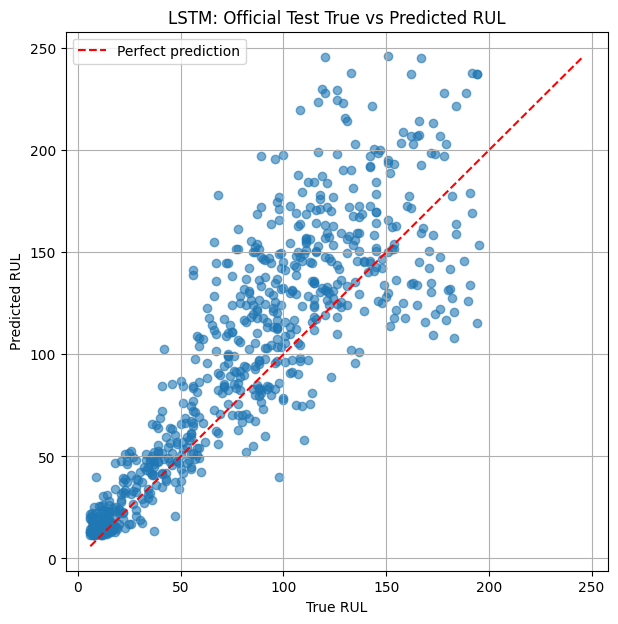

In [104]:
lstm_optimized_test_engine_summary = plot_final_test_predictions(lstm_optimized_test_results, 'LSTM')

# Saving model

In [105]:
lstm_model_path = model_dir / "final_lstm_optimized.pth"
lstm_metadata_path = model_dir / "final_lstm_optimized_metadata.joblib"
lstm_metadata_json_path = model_dir / "final_lstm_optimized_metadata.json"

torch.save(lstm_model_optimized.state_dict(), lstm_model_path)

lstm_model_metadata = {
    'model_name': 'Optimized LSTM',
    'input_size': input_size,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'window_size': window_size,
    'feature_cols': combined_features,
    'feature_count': len(combined_features),
    'epochs': optimized_num_epochs,
    'batch_size': batch_size,
    'learning_rate': 0.001,
    'device_used_for_training': str(device),
    'train_input_shape': tuple(X_seq_train.shape),
    'val_input_shape': tuple(X_seq_val.shape),
    'final_test_input_shape': tuple(X_seq_test.shape),
    'model_input_type': 'sequence_window_to_one_rul'
}

joblib.dump(lstm_model_metadata, lstm_metadata_path)

with open(lstm_metadata_json_path, "w") as f:
    json.dump(lstm_model_metadata, f, indent=2)

print(f"Saved optimized LSTM model to: {lstm_model_path}")
print(f"Saved LSTM metadata to: {lstm_metadata_path}")
print(f"Saved LSTM metadata JSON to: {lstm_metadata_json_path}")


Saved optimized LSTM model to: ..\saved_models\final_lstm_optimized.pth
Saved LSTM metadata to: ..\saved_models\final_lstm_optimized_metadata.joblib
Saved LSTM metadata JSON to: ..\saved_models\final_lstm_optimized_metadata.json


# Saving results

In [106]:
lstm_optimized_test_results.to_csv(final_results_dir / "lstm_test_results.csv", index=False)
lstm_optimized_test_summary.to_csv(final_results_dir / "lstm_test_summary.csv", index=False)
lstm_optimized_test_bucket_summary.to_csv(final_results_dir / "lstm_test_bucket_summary.csv", index=False)
lstm_optimized_test_tag_summary.to_csv(final_results_dir / "lstm_test_tag_summary.csv", index=False)

joblib.dump(lstm_optimized_test_results, final_results_dir / "lstm_test_results.joblib")
joblib.dump(lstm_optimized_test_summary, final_results_dir / "lstm_test_summary.joblib")
joblib.dump(lstm_optimized_test_bucket_summary, final_results_dir / "lstm_test_bucket_summary.joblib")
joblib.dump(lstm_optimized_test_tag_summary, final_results_dir / "lstm_test_tag_summary.joblib")

lstm_final_test_metadata = {
    'model_name': 'Optimized LSTM',
    'evaluation': 'Official Test',
    'window_size': window_size,
    'feature_count': len(combined_features),
    'feature_cols': combined_features,
    'epochs': optimized_num_epochs,
    'batch_size': batch_size,
    'x_test_shape': tuple(X_seq_test.shape),
    'n_test_engines': int(meta_seq_test['unit_id'].nunique())
}

joblib.dump(lstm_final_test_metadata, final_results_dir / "lstm_final_test_metadata.joblib")

with open(final_results_dir / "lstm_final_test_metadata.json", "w") as f:
    json.dump(lstm_final_test_metadata, f, indent=2)

print("Saved optimized LSTM final test outputs")


Saved optimized LSTM final test outputs


# Comparision table of models

In [107]:
lr_backtest_summary_final = lr_overall_summary.copy()
lr_backtest_summary_final['model'] = 'Linear Regression'
lr_backtest_summary_final['evaluation'] = 'Backtest'

rf_backtest_summary_final = rf_overall_summary.copy()
rf_backtest_summary_final['model'] = 'Random Forest'
rf_backtest_summary_final['evaluation'] = 'Backtest'

lstm_backtest_summary_final = lstm_backtest_overall_summary.copy()
lstm_backtest_summary_final['model'] = 'LSTM'
lstm_backtest_summary_final['evaluation'] = 'Backtest'

lr_test_summary_final = lr_test_summary.copy()
lr_test_summary_final['model'] = 'Linear Regression'
lr_test_summary_final['evaluation'] = 'Official Test'

rf_test_summary_final = rf_test_summary.copy()
rf_test_summary_final['model'] = 'Random Forest'
rf_test_summary_final['evaluation'] = 'Official Test'

lstm_test_summary_final = lstm_optimized_test_summary.copy()
lstm_test_summary_final['model'] = 'LSTM'
lstm_test_summary_final['evaluation'] = 'Official Test'

final_comparison_table = pd.concat([
    lr_backtest_summary_final,
    rf_backtest_summary_final,
    lstm_backtest_summary_final,
    lr_test_summary_final,
    rf_test_summary_final,
    lstm_test_summary_final
], ignore_index=True)

final_comparison_table = final_comparison_table[
    ['model', 'evaluation', 'samples', 'units', 'mae', 'rmse', 'r2',
     'mean_true_rul', 'mean_pred_rul', 'mean_error', 'mean_abs_error']
]

print(final_comparison_table)


               model     evaluation  samples  units        mae       rmse  \
0  Linear Regression       Backtest   139798    709  34.881590  47.872139   
1      Random Forest       Backtest   139798    709  29.968083  44.430025   
2               LSTM       Backtest   139798    709  29.209051  43.133328   
3  Linear Regression  Official Test      707    707  27.253372  34.190976   
4      Random Forest  Official Test      707    707  22.990410  31.834183   
5               LSTM  Official Test      707    707  24.499052  34.025108   

         r2  mean_true_rul  mean_pred_rul  mean_error  mean_abs_error  
0  0.618981     109.264331     109.033765   -0.230566       34.881590  
1  0.671803     109.264331     109.521175    0.256843       29.968083  
2  0.690681     109.264331     110.301292    1.036964       29.209051  
3  0.551822      81.437058      95.393085   13.956027       27.253372  
4  0.611478      81.437058      93.474314   12.037256       22.990410  
5  0.556159      81.437058  

# Saving final results

In [108]:
final_comparison_table.to_csv(final_results_dir / "final_model_comparison_with_lstm.csv", index=False)
joblib.dump(final_comparison_table, final_results_dir / "final_model_comparison_with_lstm.joblib")

print("Saved final comparison table with LSTM")

Saved final comparison table with LSTM


# Sorted model comparision table

In [109]:
presentation_table = final_comparison_table[
    ['model', 'evaluation', 'mae', 'rmse', 'r2']
].copy()

print(presentation_table.sort_values(['evaluation', 'rmse']))

               model     evaluation        mae       rmse        r2
2               LSTM       Backtest  29.209051  43.133328  0.690681
1      Random Forest       Backtest  29.968083  44.430025  0.671803
0  Linear Regression       Backtest  34.881590  47.872139  0.618981
4      Random Forest  Official Test  22.990410  31.834183  0.611478
5               LSTM  Official Test  24.499052  34.025108  0.556159
3  Linear Regression  Official Test  27.253372  34.190976  0.551822


# Reloading the model

In [110]:
# loaded_lstm_metadata = joblib.load(model_dir / "final_lstm_optimized_metadata.joblib")
# print("Loaded LSTM metadata:")
# print(loaded_lstm_metadata)

# loaded_lstm_model = LSTMRegressor(
#     input_size=loaded_lstm_metadata['input_size'],
#     hidden_size=loaded_lstm_metadata['hidden_size'],
#     num_layers=loaded_lstm_metadata['num_layers'],
#     dropout=loaded_lstm_metadata['dropout']
# ).to(device)

# loaded_lstm_model.load_state_dict(
#     torch.load(model_dir / "final_lstm_optimized.pth", map_location=device)
# )

# loaded_lstm_model.eval()

# print("Reloaded optimized LSTM model successfully")
# print(loaded_lstm_model)